# Esperimento 2 — Distanza tra Istituti Affini

**Domanda di ricerca**: La distanza coseno tra embedding riflette la "parentela" dottrinale tra istituti giuridici?

## Quadro matematico

### Dalla categoria alla metrica

L'Esperimento 1 ha testato una proprieta' **categoriale**: i termini si raggruppano per ramo del diritto? L'Esperimento 2 fa un passo ulteriore e testa una proprieta' **metrica**: non solo i termini si raggruppano, ma le *distanze tra essi* riflettono la prossimita' concettuale riconosciuta dalla dottrina.

In termini formali, dati due termini giuridici $A$ e $B$ con embedding $\mathbf{v}_A, \mathbf{v}_B \in \mathbb{R}^n$, la distanza coseno e':

$$d_{cos}(A, B) = 1 - \frac{\mathbf{v}_A \cdot \mathbf{v}_B}{\|\mathbf{v}_A\| \cdot \|\mathbf{v}_B\|}$$

Su vettori gia' normalizzati L2 (come quelli dell'Esperimento 1), si semplifica in:

$$d_{cos}(A, B) = 1 - \mathbf{v}_A \cdot \mathbf{v}_B = 1 - \sum_{i=1}^{n} v_{A,i} \cdot v_{B,i}$$

Il range e' $[0, 2]$: $d_{cos} = 0$ per vettori identici, $d_{cos} = 1$ per vettori ortogonali, $d_{cos} = 2$ per vettori opposti. In pratica, per embedding di modelli reali, i valori cadono tipicamente in $[0.2, 1.2]$.

### L'ipotesi da testare

Se lo spazio degli embedding preserva la struttura del diritto, allora la distanza coseno deve essere una funzione monotona crescente della "distanza dottrinale" tra istituti:

$$d_{dottrinale}(A, B) < d_{dottrinale}(C, D) \implies d_{cos}(A, B) < d_{cos}(C, D)$$

Questa e' una corrispondenza **ordinale** (preserva l'ordine dei ranghi), non necessariamente **lineare** (non richiede proporzionalita' diretta).

## Ipotesi

- **H₀** (nulla): La distanza coseno tra embedding di termini giuridici e' indipendente dalla prossimita' dottrinale. Le distribuzioni di distanza per coppie "vicine", "medie" e "lontane" provengono dalla stessa popolazione.
- **H₁a** (ordinamento): $d_{cos}(\text{vicine}) < d_{cos}(\text{medie}) < d_{cos}(\text{lontane})$
- **H₁b** (correlazione): $\rho_{\text{Spearman}}(\text{distanza umana}, \text{distanza coseno}) > 0$, con $p < 0.01$
- **H₁c** (robustezza): l'ordinamento si mantiene attraverso almeno 2 modelli su 3

### Soglie interpretative per $\rho$ di Spearman

| $\rho$ | Interpretazione |
|--------|----------------|
| $> 0.6$ | La geometria riflette la sistematica giuridica |
| $0.4 - 0.6$ | Riflette le macro-distinzioni ma non le sfumature |
| $0.2 - 0.4$ | Solo la distinzione intra-ramo/inter-ramo e' catturata |
| $< 0.2$ | La distanza coseno non preserva la prossimita' dottrinale |

## Fondamento giuridico

La nozione di "distanza" tra istituti non e' arbitraria. Si fonda su criteri consolidati nella dogmatica:

- **Identita' di ratio legis**: istituti che perseguono la stessa funzione sono "vicini" (dolo/colpa: stesso bene tutelato, diversa rimproverabilita')
- **Appartenenza sistematica**: il Codice Civile ordina la materia per prossimita' concettuale (Libro III proprieta', Libro IV obbligazioni)
- **Rete dei rinvii normativi**: i rinvii tra norme creano una topologia implicita del diritto (cfr. Bobbio, *Teoria dell'ordinamento giuridico*, 1960)

**Obiezione**: la "distanza dottrinale" e' in parte soggettiva — un penalista e un civilista non assegneranno gli stessi punteggi. Questo e' controllato nella variante con annotazione esperta (Sezione 6), dove si misura l'accordo inter-valutatore con Krippendorff's alpha.

## Riferimenti
- Kriegeskorte et al. (2008) — Representational Similarity Analysis: confronto tra matrici di dissimilarita'
- Ethayarajh (2019) — Anisotropia degli embedding contestuali: la distanza media non e' zero
- Kozlowski et al. (2019) — Geometry of Culture: distanze geometriche riflettono distanze culturali
- Bobbio (1960) — Teoria dell'ordinamento giuridico: struttura sistematica delle norme

## Protocollo
1. Caricare embedding dall'Esperimento 1 (stessi 294 termini, stessi modelli)
2. Definire 30 coppie a distanza giuridica nota: 10 vicine, 10 medie, 10 lontane
3. Calcolare la distanza coseno per ciascuna coppia
4. Test statistici: Kruskal-Wallis, Mann-Whitney U pairwise, Jonckheere-Terpstra
5. Controllo confound: overlap lessicale, baseline di anisotropia
6. (Variante) Annotazione esperta: 5 giuristi valutano 1-10, poi Spearman $\rho$

In [1]:
# == Configurazione ambiente ======================================
# Esperimento 2: Distanza tra Istituti Affini
# Progetto "Norme come Oggetti Geometrici"

%matplotlib inline

import json
import logging
import warnings
from pathlib import Path
from collections import Counter
from dataclasses import dataclass, field
from itertools import combinations

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
from scipy.spatial.distance import cosine
from scipy.stats import (
    kruskal,
    mannwhitneyu,
    spearmanr,
    pearsonr,
)

warnings.filterwarnings("ignore", category=FutureWarning)
logging.basicConfig(level=logging.INFO, format="%(levelname)s | %(message)s")
logger = logging.getLogger("exp02")

# Palette Okabe-Ito
PALETTE_GROUPS = {
    "vicine": "#009E73",    # verde — coppie vicine
    "medie": "#E69F00",     # arancione — coppie medie
    "lontane": "#D55E00",   # rosso — coppie lontane
}
PALETTE_RAMI = {
    "penale": "#E69F00",
    "civile": "#56B4E9",
    "amministrativo": "#009E73",
    "costituzionale": "#F0E442",
    "processuale": "#0072B2",
    "internazionale": "#D55E00",
}
sns.set_theme(style="whitegrid", font_scale=1.1)

SEED = 42
np.random.seed(SEED)

print("Ambiente configurato.")

Ambiente configurato.


## Sezione 1: Caricamento dati dall'Esperimento 1

### Perche' riusare gli embedding

L'Esperimento 2 opera sugli **stessi embedding** dell'Esperimento 1. Ogni termine del lessico (294 termini) e' stato gia' trasformato in un vettore numerico da ciascun modello. Qui ci limitiamo a selezionare 60 di questi vettori (i termini coinvolti nelle 30 coppie) e a calcolarne le distanze.

### Prodotto scalare su vettori normalizzati

Poiche' nell'Esperimento 1 tutti i vettori sono stati normalizzati L2 (ciascun vettore ha norma unitaria, $\|\mathbf{v}\| = 1$), la distanza coseno tra due termini si calcola con un semplice prodotto scalare:

$$d_{cos}(A, B) = 1 - \mathbf{v}_A \cdot \mathbf{v}_B = 1 - \sum_{i=1}^{n} v_{A,i} \cdot v_{B,i}$$

Questa operazione e' numericamente stabile e computazionalmente efficiente (un unico prodotto scalare per coppia, senza divisioni).

### Dipendenza dall'Esperimento 1

Questa cella carica:
- `lessico.json`: i 294 termini con le loro annotazioni (ramo, sotto-ramo, trasversale)
- `embeddings_*.npy`: le matrici di embedding salvate (una per modello)

Se l'Esperimento 1 non e' stato eseguito, la cella successiva offre un fallback per estrarre gli embedding in-place.

In [2]:
# == Caricamento dati Esperimento 1 ================================
# Se l'Esperimento 1 e' stato eseguito, i risultati sono in ../output/exp01_tassonomia/
# Altrimenti: eseguire prima l'Esperimento 1.

EXP01_DIR = Path("../output/exp01_tassonomia")

# Carica lessico
with open(EXP01_DIR / "lessico.json", "r", encoding="utf-8") as f:
    LESSICO = json.load(f)
df = pd.DataFrame(LESSICO)

# Indice: termine -> posizione nel lessico
termine_to_idx = {t["termine"]: i for i, t in enumerate(LESSICO)}

# Carica embedding per ciascun modello disponibile
embeddings = {}
for npy_file in sorted(EXP01_DIR.glob("embeddings_*.npy")):
    label = npy_file.stem.replace("embeddings_", "").replace("_", " ")
    embeddings[label] = np.load(npy_file)

print(f"Lessico: {len(LESSICO)} termini")
print(f"Modelli caricati: {len(embeddings)}")
for label, emb in embeddings.items():
    print(f"  {label}: {emb.shape}")

# Se l'Esperimento 1 non e' stato ancora eseguito, questa cella fallira'.
# In tal caso, usare LOAD_FROM_SCRATCH = True per estrarre gli embedding qui.
LOAD_FROM_SCRATCH = False

if LOAD_FROM_SCRATCH or len(embeddings) == 0:
    print("\nEmbedding non trovati. Eseguire prima l'Esperimento 1,")
    print("oppure impostare LOAD_FROM_SCRATCH = True e decommentare la cella successiva.")

Lessico: 294 termini
Modelli caricati: 4
  E5-multilingual-large: (294, 1024)
  MiniLM-multilingual: (294, 384)
  OpenAI-3-large: (294, 3072)
  Qwen3-Emb-8B: (294, 4096)


In [3]:
# == Fallback: estrazione embedding in-place ======================
# Decommentare SOLO se l'Esperimento 1 non e' stato eseguito.
#
# import torch, gc
# from sentence_transformers import SentenceTransformer
# from sklearn.preprocessing import normalize
#
# MODELS_DIR = Path("../models")
# termini = df["termine"].tolist()
#
# for cfg in [
#     {"label": "E5-multilingual-large", "name": "intfloat/multilingual-e5-large-instruct", "prefix": "query: "},
#     {"label": "MiniLM-multilingual", "name": "sentence-transformers/paraphrase-multilingual-MiniLM-L12-v2", "prefix": ""},
# ]:
#     model = SentenceTransformer(cfg["name"], cache_folder=str(MODELS_DIR), trust_remote_code=True)
#     texts = [f"{cfg['prefix']}{t}" for t in termini] if cfg["prefix"] else termini
#     vecs = model.encode(texts, convert_to_numpy=True, show_progress_bar=True, batch_size=32)
#     embeddings[cfg["label"]] = normalize(vecs, norm="l2")
#     del model; gc.collect()
#
# print(f"Embedding estratti per {len(embeddings)} modelli.")

print("Cella fallback: decommentare se Esperimento 1 non eseguito.")

Cella fallback: decommentare se Esperimento 1 non eseguito.


## Sezione 2: Definizione delle 30 coppie

### Il problema della selezione

La scelta delle coppie e' il passaggio piu' delicato dell'esperimento. Due rischi opposti:
- **Cherry-picking** (circolarita'): se scegliamo coppie dopo aver visto le distanze coseno, l'esperimento e' invalido. Le coppie sono fissate **prima** di qualsiasi calcolo.
- **Bias di conferma**: se il ricercatore (giurista) sceglie inconsciamente coppie che confermano la sua ipotesi, i risultati sono inflazionati. Per mitigare: le motivazioni dottrinali sono esplicitate per ciascuna coppia, rendendo la selezione verificabile da altri giuristi.

### Criteri di classificazione

Le 30 coppie sono suddivise in tre gruppi da 10, basati sulla **distanza dottrinale** — un concetto giuridico, non numerico:

**Coppie vicine** ($d_{\text{dottrinale}} \approx \text{bassa}$):
- Stesso sotto-ramo del diritto (es. furto/rapina: entrambi reati contro il patrimonio)
- Stessa funzione giuridica con variazione di un solo tratto (es. dolo/colpa: stesso bene tutelato, diversa rimproverabilita')
- Relazione di genere a specie (es. ipoteca/pegno: entrambe garanzie reali)

**Coppie medie** ($d_{\text{dottrinale}} \approx \text{media}$):
- Stesso macro-ambito ma funzione diversa (es. contratto/reato: entrambi atti giuridici)
- Relazione trasversale nota in dottrina (es. confisca/espropriazione: ablazione patrimoniale in rami diversi)
- Analogia strutturale senza appartenenza comune (es. presunzione di innocenza/onere della prova: principi processuali in ambiti diversi)

**Coppie lontane** ($d_{\text{dottrinale}} \approx \text{alta}$):
- Rami del diritto diversi senza intersezione (es. ergastolo/fideiussione: penale vs. civile)
- Nessun collegamento dottrinale noto, nessun rinvio normativo, nessuna analogia funzionale
- Selezionate per massimizzare la distanza tassonomica nel sistema delle fonti

### Bilanciamento

Il design e' bilanciato: 10 coppie per gruppo. Questo assicura che i test non-parametrici (Kruskal-Wallis, Jonckheere-Terpstra) abbiano la stessa potenza per tutti i confronti. Un design sbilanciato (es. 5 vicine, 15 lontane) ridurrebbe la potenza per i confronti con il gruppo piu' piccolo.

### Copertura dei rami

Le 30 coppie coinvolgono termini da tutti e 6 i rami del diritto dell'Esperimento 1 (penale, civile, amministrativo, costituzionale, processuale, internazionale), assicurando che i risultati non siano specifici di un singolo ramo.

### Anti-circolarita'

Per ciascuna coppia la cella seguente riporta:
- **termine_a**, **termine_b**: i due termini (devono entrambi appartenere al lessico di 294 termini)
- **gruppo**: classificazione dottrinale (vicine/medie/lontane)
- **motivazione**: il riferimento normativo o dottrinale che giustifica la classificazione

La motivazione rende la classificazione **falsificabile**: un altro giurista puo' contestarla con argomenti dottrinali. Questo e' un vantaggio epistemologico rispetto a classificazioni implicite o non motivate.

In [4]:
# == Definizione delle 30 coppie ==================================
# Ciascuna coppia ha: termine_a, termine_b, gruppo (vicine/medie/lontane),
# motivazione dottrinale.
#
# Le coppie sono fissate PRIMA di calcolare le distanze coseno
# per evitare cherry-picking (rischio di circolarita').

COPPIE = [
    # =================================================================
    # COPPIE VICINE (10)
    # Stesso sotto-ramo o istituti strettamente affini
    # =================================================================
    {
        "a": "dolo", "b": "colpa", "gruppo": "vicine",
        "motivazione": "Elementi soggettivi alternativi del reato (artt. 42-43 c.p.)",
    },
    {
        "a": "proprieta'", "b": "possesso", "gruppo": "vicine",
        "motivazione": "Situazioni reali: titolarita' vs. fatto (artt. 832, 1140 c.c.)",
    },
    {
        "a": "furto", "b": "rapina", "gruppo": "vicine",
        "motivazione": "Reati contro il patrimonio, rapina = furto + violenza (artt. 624, 628 c.p.)",
    },
    {
        "a": "annullabilita'", "b": "nullita'", "gruppo": "vicine",
        "motivazione": "Patologie del contratto: stessa funzione, diversa gravita' (artt. 1418, 1425 c.c.)",
    },
    {
        "a": "decreto legislativo", "b": "decreto-legge", "gruppo": "vicine",
        "motivazione": "Atti normativi del Governo, stesso rango, diverso presupposto (artt. 76-77 Cost.)",
    },
    {
        "a": "appello", "b": "ricorso per Cassazione", "gruppo": "vicine",
        "motivazione": "Impugnazioni ordinarie: gradi successivi del giudizio",
    },
    {
        "a": "ipoteca", "b": "pegno", "gruppo": "vicine",
        "motivazione": "Garanzie reali: immobiliare vs. mobiliare (artt. 2808, 2784 c.c.)",
    },
    {
        "a": "ricorso al TAR", "b": "ricorso al Consiglio di Stato", "gruppo": "vicine",
        "motivazione": "Gradi della giustizia amministrativa",
    },
    {
        "a": "trattato internazionale", "b": "consuetudine internazionale", "gruppo": "vicine",
        "motivazione": "Fonti primarie del diritto internazionale pubblico",
    },
    {
        "a": "indagini preliminari", "b": "udienza preliminare", "gruppo": "vicine",
        "motivazione": "Fasi consecutive del procedimento penale (Libro V CPP)",
    },

    # =================================================================
    # COPPIE MEDIE (10)
    # Stesso macro-ambito o relazione trasversale nota
    # =================================================================
    {
        "a": "dolo", "b": "inadempimento", "gruppo": "medie",
        "motivazione": "Elemento soggettivo penale vs. patologia dell'obbligazione — collegati via responsabilita'",
    },
    {
        "a": "contratto", "b": "reato", "gruppo": "medie",
        "motivazione": "Atti giuridici di natura opposta: autonomia privata vs. illecito",
    },
    {
        "a": "proprieta'", "b": "espropriazione per pubblica utilita'", "gruppo": "medie",
        "motivazione": "Diritto reale vs. la sua limitazione pubblica — collegati ma antagonisti",
    },
    {
        "a": "sentenza", "b": "legge ordinaria", "gruppo": "medie",
        "motivazione": "Atti giuridici produttivi: giurisdizionale vs. legislativo",
    },
    {
        "a": "presunzione di innocenza", "b": "onere della prova", "gruppo": "medie",
        "motivazione": "Principi processuali correlati ma in ambiti diversi (penale vs. civile)",
    },
    {
        "a": "sanzione amministrativa", "b": "pena detentiva", "gruppo": "medie",
        "motivazione": "Sanzioni di rami diversi: stessa funzione, diverso ordinamento",
    },
    {
        "a": "Corte Costituzionale", "b": "Corte dei Conti", "gruppo": "medie",
        "motivazione": "Organi giurisdizionali distinti, competenze non sovrapposte",
    },
    {
        "a": "matrimonio", "b": "contratto", "gruppo": "medie",
        "motivazione": "Natura contrattuale del matrimonio dibattuta; stessa area, funzione diversa",
    },
    {
        "a": "confisca", "b": "espropriazione", "gruppo": "medie",
        "motivazione": "Ablazione patrimoniale: penale vs. civile/amministrativa",
    },
    {
        "a": "legittima difesa", "b": "stato di necessita'", "gruppo": "medie",
        "motivazione": "Scriminanti: stessa funzione (escludere antigiuridicita'), presupposti diversi",
    },

    # =================================================================
    # COPPIE LONTANE (10)
    # Rami diversi, nessuna relazione dottrinale diretta
    # =================================================================
    {
        "a": "dolo", "b": "servitu' prediale", "gruppo": "lontane",
        "motivazione": "Elemento soggettivo penale vs. diritto reale su cosa altrui — nessun collegamento",
    },
    {
        "a": "litispendenza", "b": "enfiteusi", "gruppo": "lontane",
        "motivazione": "Eccezione processuale vs. diritto reale arcaico — nessun collegamento",
    },
    {
        "a": "ergastolo", "b": "fideiussione", "gruppo": "lontane",
        "motivazione": "Sanzione penale massima vs. garanzia personale — nessun collegamento",
    },
    {
        "a": "immunita' diplomatica", "b": "pignoramento", "gruppo": "lontane",
        "motivazione": "Diritto internazionale vs. esecuzione forzata — nessun collegamento",
    },
    {
        "a": "referendum abrogativo", "b": "ricettazione", "gruppo": "lontane",
        "motivazione": "Fonte del diritto vs. reato contro il patrimonio — nessun collegamento",
    },
    {
        "a": "vincolo paesaggistico", "b": "preterintenzione", "gruppo": "lontane",
        "motivazione": "Potere amministrativo vs. elemento soggettivo penale — nessun collegamento",
    },
    {
        "a": "Corte Penale Internazionale", "b": "comodato", "gruppo": "lontane",
        "motivazione": "Organo internazionale vs. contratto reale gratuito — nessun collegamento",
    },
    {
        "a": "silenzio-assenso", "b": "custodia cautelare", "gruppo": "lontane",
        "motivazione": "Semplificazione amministrativa vs. misura processuale penale — nessun collegamento",
    },
    {
        "a": "zona economica esclusiva", "b": "clausola penale", "gruppo": "lontane",
        "motivazione": "Diritto del mare vs. clausola contrattuale — nessun collegamento",
    },
    {
        "a": "federalismo fiscale", "b": "omicidio", "gruppo": "lontane",
        "motivazione": "Organizzazione territoriale vs. reato — massima distanza concettuale",
    },
]

df_coppie = pd.DataFrame(COPPIE)

# Verifica: tutti i termini devono essere nel lessico
missing = []
for c in COPPIE:
    for key in ["a", "b"]:
        if c[key] not in termine_to_idx:
            missing.append(c[key])
if missing:
    print(f"ERRORE: termini mancanti nel lessico: {set(missing)}")
else:
    print(f"Tutte le 30 coppie verificate: tutti i termini presenti nel lessico.")

print(f"\nDistribuzione per gruppo:")
print(df_coppie["gruppo"].value_counts().to_string())

Tutte le 30 coppie verificate: tutti i termini presenti nel lessico.

Distribuzione per gruppo:
gruppo
vicine     10
medie      10
lontane    10


## Sezione 3: Calcolo delle distanze coseno

### La metrica

Per ciascuna delle 30 coppie $(A, B)$ e per ciascun modello, calcoliamo:

$$d_{cos}(A, B) = 1 - \hat{\mathbf{v}}_A \cdot \hat{\mathbf{v}}_B$$

dove $\hat{\mathbf{v}}$ indica il vettore normalizzato L2.

### Range dei valori

- $d_{cos} = 0$: i due termini hanno embedding identici (vettori paralleli, angolo $\theta = 0°$)
- $d_{cos} = 1$: i due termini sono ortogonali (angolo $\theta = 90°$, nessuna relazione lineare)
- $d_{cos} = 2$: i due termini hanno embedding opposti (angolo $\theta = 180°$, estremamente raro in pratica)

In pratica, la maggior parte delle distanze coseno tra embedding di termini reali cade nell'intervallo $[0.3, 1.0]$. Valori sotto 0.3 indicano forte affinita' semantica; valori sopra 0.8 indicano scarsa relazione.

### Relazione con la similarita' coseno

La **similarita' coseno** e' il complemento della distanza: $\text{sim}_{cos} = 1 - d_{cos} = \hat{\mathbf{v}}_A \cdot \hat{\mathbf{v}}_B$. Quando si dice che due termini hanno similarita' coseno di 0.85, la distanza e' $1 - 0.85 = 0.15$.

### Baseline di anisotropia

Ethayarajh (2019) ha dimostrato che gli embedding contestuali sono **anisotropi**: non sono distribuiti uniformemente sulla sfera unitaria, ma tendono a concentrarsi in un cono. Questo significa che la distanza coseno media tra due termini qualsiasi non e' $1.0$ (ortogonalita') ma un valore inferiore (tipicamente $0.4\text{--}0.7$ a seconda del modello).

Per interpretare correttamente le distanze delle nostre coppie, calcoliamo la **baseline**: la distanza coseno media su 5.000 coppie casuali dal lessico. Le coppie "vicine" devono essere significativamente sotto questa baseline; le "lontane" sopra (o almeno indistinguibili da essa).

In [5]:
# == Calcolo distanze coseno =======================================

results = {}  # model_label -> dict con distanze e metriche

for model_label, emb in embeddings.items():
    print(f"\n{'='*70}")
    print(f"  Modello: {model_label}")
    print(f"{'='*70}")

    distanze = []
    for c in COPPIE:
        idx_a = termine_to_idx[c["a"]]
        idx_b = termine_to_idx[c["b"]]
        # Su vettori normalizzati: d_cos = 1 - dot
        d = 1.0 - np.dot(emb[idx_a], emb[idx_b])
        distanze.append(d)

    # Aggiungi le distanze al DataFrame delle coppie
    col_name = f"d_cos_{model_label}"
    df_coppie[col_name] = distanze

    # Stampa per gruppo
    for gruppo in ["vicine", "medie", "lontane"]:
        mask = df_coppie["gruppo"] == gruppo
        vals = df_coppie.loc[mask, col_name]
        print(f"\n  {gruppo.upper():10s}  media={vals.mean():.4f}  std={vals.std():.4f}  "
              f"min={vals.min():.4f}  max={vals.max():.4f}")

    results[model_label] = {"col": col_name, "distanze": np.array(distanze)}

# Tabella completa
print(f"\n{'='*70}")
print("Tabella delle 30 coppie con distanze coseno:")
print(f"{'='*70}")
display_cols = ["a", "b", "gruppo"] + [r["col"] for r in results.values()]
display(df_coppie[display_cols])


  Modello: E5-multilingual-large

  VICINE      media=0.0725  std=0.0315  min=0.0280  max=0.1303

  MEDIE       media=0.1139  std=0.0186  min=0.0797  max=0.1334

  LONTANE     media=0.1500  std=0.0190  min=0.1208  max=0.1848

  Modello: MiniLM-multilingual

  VICINE      media=0.3607  std=0.1974  min=0.1130  max=0.6794

  MEDIE       media=0.4427  std=0.1152  min=0.2887  max=0.6576

  LONTANE     media=0.6632  std=0.1378  min=0.3949  max=0.8612

  Modello: OpenAI-3-large

  VICINE      media=0.3564  std=0.1072  min=0.1901  max=0.5688

  MEDIE       media=0.5183  std=0.0933  min=0.3199  max=0.6501

  LONTANE     media=0.6894  std=0.0504  min=0.6139  max=0.7726

  Modello: Qwen3-Emb-8B

  VICINE      media=0.1906  std=0.0840  min=0.0751  max=0.3775

  MEDIE       media=0.2870  std=0.0699  min=0.1698  max=0.3650

  LONTANE     media=0.4121  std=0.0572  min=0.3429  max=0.5231

Tabella delle 30 coppie con distanze coseno:


,a,b,gruppo,d_cos_E5-multilingual-large,d_cos_MiniLM-multilingual,d_cos_OpenAI-3-large,d_cos_Qwen3-Emb-8B
0,dolo,colpa,vicine,0.103582,0.201928,0.568752,0.242250
1,proprieta',possesso,vicine,0.046578,0.317372,0.364158,0.140416
2,furto,rapina,vicine,0.075264,0.301982,0.349665,0.377492
3,annullabilita',nullita',vicine,0.066915,0.552494,0.400139,0.228190
4,decreto legislativo,decreto-legge,vicine,0.028026,0.113018,0.229809,0.075143
5,appello,ricorso per Cassazione,vicine,0.100900,0.324108,0.366151,0.212067
6,ipoteca,pegno,vicine,0.130275,0.679445,0.452264,0.160643
7,ricorso al TAR,ricorso al Consiglio di Stato,vicine,0.047593,0.651370,0.190112,0.106814
8,trattato internazionale,consuetudine internazionale,vicine,0.076052,0.202918,0.341845,0.173276
9,indagini preliminari,udienza preliminare,vicine,0.050079,0.261972,0.301225,0.189928


In [6]:
# == Baseline di anisotropia ======================================
# Ethayarajh (2019): gli embedding contestuali sono anisotropi.
# La distanza coseno media tra coppie casuali NON e' zero.
# Calcoliamo la baseline per ciascun modello.

N_RANDOM_PAIRS = 5000

print("Baseline di anisotropia (distanza coseno media tra coppie casuali):")
print("=" * 70)

for model_label, emb in embeddings.items():
    n = len(emb)
    # Campiona coppie casuali
    idx_pairs = np.random.choice(n, size=(N_RANDOM_PAIRS, 2), replace=True)
    # Escludi coppie identiche
    mask_valid = idx_pairs[:, 0] != idx_pairs[:, 1]
    idx_pairs = idx_pairs[mask_valid]

    random_dists = np.array([
        1.0 - np.dot(emb[i], emb[j]) for i, j in idx_pairs
    ])

    results[model_label]["baseline_mean"] = random_dists.mean()
    results[model_label]["baseline_std"] = random_dists.std()
    results[model_label]["baseline_q25"] = np.percentile(random_dists, 25)
    results[model_label]["baseline_q75"] = np.percentile(random_dists, 75)

    print(f"\n  {model_label}:")
    print(f"    Media baseline  = {random_dists.mean():.4f} +/- {random_dists.std():.4f}")
    print(f"    IQR baseline    = [{np.percentile(random_dists, 25):.4f}, {np.percentile(random_dists, 75):.4f}]")

    # Confronto con i gruppi
    col = results[model_label]["col"]
    for gruppo in ["vicine", "medie", "lontane"]:
        mask = df_coppie["gruppo"] == gruppo
        g_mean = df_coppie.loc[mask, col].mean()
        diff = g_mean - random_dists.mean()
        print(f"    {gruppo:10s}: media={g_mean:.4f}  (delta vs baseline: {diff:+.4f})")

Baseline di anisotropia (distanza coseno media tra coppie casuali):

  E5-multilingual-large:
    Media baseline  = 0.1409 +/- 0.0225
    IQR baseline    = [0.1277, 0.1556]
    vicine    : media=0.0725  (delta vs baseline: -0.0684)
    medie     : media=0.1139  (delta vs baseline: -0.0271)
    lontane   : media=0.1500  (delta vs baseline: +0.0091)

  MiniLM-multilingual:
    Media baseline  = 0.6145 +/- 0.1404
    IQR baseline    = [0.5268, 0.7115]
    vicine    : media=0.3607  (delta vs baseline: -0.2539)
    medie     : media=0.4427  (delta vs baseline: -0.1718)
    lontane   : media=0.6632  (delta vs baseline: +0.0487)

  OpenAI-3-large:
    Media baseline  = 0.6260 +/- 0.0787
    IQR baseline    = [0.5799, 0.6757]
    vicine    : media=0.3564  (delta vs baseline: -0.2696)
    medie     : media=0.5183  (delta vs baseline: -0.1077)
    lontane   : media=0.6894  (delta vs baseline: +0.0633)

  Qwen3-Emb-8B:
    Media baseline  = 0.3670 +/- 0.0565
    IQR baseline    = [0.3308, 0.4046]

## Sezione 4: Test statistici

L'ipotesi H₁a prevede un **ordinamento**: $d_{cos}(\text{vicine}) < d_{cos}(\text{medie}) < d_{cos}(\text{lontane})$. Questo richiede test non-parametrici specifici, perche':
- I campioni sono piccoli ($n = 10$ per gruppo)
- Non possiamo assumere normalita' delle distanze coseno
- L'ipotesi alternativa e' **ordinata**, non generica

Usiamo tre test complementari, ciascuno con un ruolo distinto.

---

### Test 1 — Kruskal-Wallis H-test

**Domanda**: almeno uno dei 3 gruppi ha distribuzione diversa dagli altri?

Il test di Kruskal-Wallis e' l'analogo non-parametrico dell'ANOVA a una via. Opera sui **ranghi** anziche' sui valori originali.

**Procedimento**:
1. Si ordinano tutte le $N = n_1 + n_2 + n_3 = 30$ osservazioni in un'unica classifica
2. Si calcolano i ranghi medi $\bar{R}_i$ per ciascun gruppo $i$
3. La statistica $H$ misura la varianza tra i ranghi medi dei gruppi:

$$H = \frac{12}{N(N+1)} \sum_{i=1}^{k} n_i \left(\bar{R}_i - \frac{N+1}{2}\right)^2$$

dove $k = 3$ e' il numero di gruppi, $n_i$ la dimensione del gruppo $i$, $N = \sum n_i$.

Sotto $H_0$, $H \sim \chi^2(k-1) = \chi^2(2)$ asintoticamente (approssimazione valida per $n_i \geq 5$).

**Limite**: il test di Kruskal-Wallis rileva *qualsiasi* differenza tra gruppi, non specificamente un ordinamento. Se il risultato e' significativo, non sappiamo ancora *quale* coppia di gruppi differisce.

---

### Test 2 — Mann-Whitney U pairwise con correzione di Bonferroni

**Domanda**: per ciascuna coppia di gruppi, il primo ha valori stocasticamente minori del secondo?

Il test di Mann-Whitney U confronta due campioni indipendenti. Per due campioni $X = \{x_1, \ldots, x_m\}$ e $Y = \{y_1, \ldots, y_n\}$:

$$U = \sum_{i=1}^{m} \sum_{j=1}^{n} S(x_i, y_j), \qquad S(x_i, y_j) = \begin{cases} 1 & \text{se } x_i < y_j \\ 0.5 & \text{se } x_i = y_j \\ 0 & \text{se } x_i > y_j \end{cases}$$

$U$ conta le coppie $(x_i, y_j)$ in cui $X$ "batte" $Y$. Il massimo e' $U_{\max} = m \cdot n$ (separazione perfetta).

**Correzione di Bonferroni**: eseguiamo 3 confronti (vicine vs medie, medie vs lontane, vicine vs lontane), quindi la soglia di significativita' diventa:

$$\alpha_{\text{adj}} = \frac{\alpha}{m} = \frac{0.05}{3} = 0.0167$$

Questo controlla il **tasso di errore per famiglia** (FWER): la probabilita' che almeno un falso positivo compaia tra i 3 test.

**Direzione**: usiamo il test **unilaterale** (`alternative='less'`), perche' H₁ predice la direzione: $d_{\text{vicine}} < d_{\text{medie}} < d_{\text{lontane}}$.

---

### Test 3 — Jonckheere-Terpstra per alternativa ordinata

**Domanda**: le distribuzioni seguono l'ordinamento predetto $\text{vicine} \prec \text{medie} \prec \text{lontane}$?

Questo test e' piu' potente del Kruskal-Wallis quando l'ipotesi alternativa specifica un **ordine tra gruppi** (non solo "almeno uno diverso").

**Statistica JT**: conta le coppie concordanti tra tutti i gruppi ordinati:

$$JT = \sum_{i < j} \sum_{a \in G_i} \sum_{b \in G_j} S(a, b)$$

dove $G_1 = \text{vicine}$, $G_2 = \text{medie}$, $G_3 = \text{lontane}$, e $S$ e' la stessa funzione segno del Mann-Whitney. Il conteggio copre: (vicine, medie), (vicine, lontane), (medie, lontane).

**Valore atteso sotto H₀**: se non c'e' ordinamento, $E[JT] = \frac{N^2 - \sum n_i^2}{4}$.

**p-value via permutazione**: poiche' la distribuzione asintotica di JT e' sensibile ai piccoli campioni, calcoliamo il p-value tramite 10.000 permutazioni:

1. Si mescolano casualmente le $N = 30$ osservazioni
2. Si ricalcola $JT_{\text{perm}}$ per la nuova assegnazione ai gruppi
3. Si ripete 10.000 volte per ottenere la distribuzione nulla
4. $p = \frac{\#\{JT_{\text{perm}} \geq JT_{\text{obs}}\} + 1}{B + 1}$ (test unilaterale, con correzione di continuita')

**Perche' e' piu' potente**: il Kruskal-Wallis usa $k - 1 = 2$ gradi di liberta' per qualsiasi scostamento dalla H₀. Il JT concentra tutta la potenza statistica su una singola direzione (l'ordinamento predetto), ottenendo p-value piu' bassi quando l'ordinamento effettivamente sussiste.

---

### Effect size — Cliff's delta ($\delta$)

I p-value indicano se l'effetto esiste, ma non **quanto e' grande**. Il Cliff's delta e' la misura di effect size non-parametrica associata al Mann-Whitney:

$$\delta = \frac{\#\{x_i > y_j\} - \#\{x_i < y_j\}}{m \cdot n}$$

dove $m, n$ sono le dimensioni dei due campioni. Il range e' $[-1, +1]$:
- $\delta = +1$: ogni valore di $X$ supera ogni valore di $Y$ (separazione perfetta)
- $\delta = 0$: i due campioni sono identici nella distribuzione
- $\delta = -1$: ogni valore di $Y$ supera ogni valore di $X$

**Soglie interpretative** (Romano et al., 2006):

| $|\delta|$ | Interpretazione |
|-----------|----------------|
| $< 0.147$ | Trascurabile (overlap quasi completo) |
| $0.147 - 0.330$ | Piccolo |
| $0.330 - 0.474$ | Medio |
| $\geq 0.474$ | Grande (overlap limitato) |

**Relazione con Mann-Whitney**: $\delta = \frac{2U}{mn} - 1$. Cliff's delta e' la versione normalizzata della statistica $U$.

---

### Schema riassuntivo dei tre test

| Test | H₀ | H₁ | Potere |
|------|----|----|--------|
| Kruskal-Wallis | Tutte le distribuzioni uguali | Almeno una diversa | Generico |
| Mann-Whitney (×3) | $d_A = d_B$ | $d_A < d_B$ (unilaterale) | Per coppia |
| Jonckheere-Terpstra | Nessun ordinamento | $d_V \prec d_M \prec d_L$ | Massimo per ipotesi ordinata |

Se tutti e tre confermano, l'evidenza per l'ordinamento e' robusta. Se JT e' significativo ma KW no, l'ordinamento e' presente ma la varianza intra-gruppo e' alta.

In [7]:
# == Test statistici ===============================================

def cliffs_delta(x, y):
    """Cliff's delta: effect size non-parametrico."""
    n_x, n_y = len(x), len(y)
    more = sum(1 for xi in x for yj in y if xi > yj)
    less = sum(1 for xi in x for yj in y if xi < yj)
    return (more - less) / (n_x * n_y)


def jonckheere_terpstra(groups, n_perm=10000):
    """Test di Jonckheere-Terpstra per alternativa ordinata.

    H1: group_0 < group_1 < ... < group_k (stochasticamente).
    La statistica conta le coppie concordanti tra gruppi ordinati.
    p-value via permutazione.
    """
    def _jt_stat(grps):
        jt = 0.0
        for i in range(len(grps)):
            for j in range(i + 1, len(grps)):
                for xi in grps[i]:
                    for xj in grps[j]:
                        if xi < xj:
                            jt += 1.0
                        elif xi == xj:
                            jt += 0.5
        return jt

    jt_obs = _jt_stat(groups)
    all_vals = np.concatenate(groups)
    sizes = [len(g) for g in groups]
    jt_perm = np.zeros(n_perm)
    for p in range(n_perm):
        perm = np.random.permutation(all_vals)
        pgrps = []
        idx = 0
        for s in sizes:
            pgrps.append(perm[idx:idx + s])
            idx += s
        jt_perm[p] = _jt_stat(pgrps)

    # One-tailed: H1 dice che JT_obs e' grande
    p_value = (np.sum(jt_perm >= jt_obs) + 1) / (n_perm + 1)
    return jt_obs, p_value, jt_perm


ALPHA = 0.05
BONFERRONI_ALPHA = ALPHA / 3  # 3 confronti pairwise

for model_label in results:
    col = results[model_label]["col"]
    print(f"\n{'='*70}")
    print(f"  {model_label}")
    print(f"{'='*70}")

    # Estrai i 3 gruppi
    d_vicine = df_coppie.loc[df_coppie["gruppo"] == "vicine", col].values
    d_medie = df_coppie.loc[df_coppie["gruppo"] == "medie", col].values
    d_lontane = df_coppie.loc[df_coppie["gruppo"] == "lontane", col].values

    # --- Kruskal-Wallis ---
    kw_stat, kw_p = kruskal(d_vicine, d_medie, d_lontane)
    sig_kw = "***" if kw_p < 0.001 else "**" if kw_p < 0.01 else "*" if kw_p < 0.05 else "n.s."
    print(f"\n  Kruskal-Wallis: H={kw_stat:.4f}, p={kw_p:.6f} {sig_kw}")

    # --- Mann-Whitney pairwise (Bonferroni) ---
    print(f"\n  Mann-Whitney U pairwise (alpha_adj={BONFERRONI_ALPHA:.4f}):")
    pairs_mw = [("vicine", "medie", d_vicine, d_medie),
                ("medie", "lontane", d_medie, d_lontane),
                ("vicine", "lontane", d_vicine, d_lontane)]
    for name_a, name_b, da, db in pairs_mw:
        # alternative='less': H1 dice che da e' stocasticamente minore di db
        u_stat, u_p = mannwhitneyu(da, db, alternative="less")
        cd = cliffs_delta(da.tolist(), db.tolist())
        sig = "*" if u_p < BONFERRONI_ALPHA else "n.s."
        size = ("grande" if abs(cd) >= 0.474 else "medio" if abs(cd) >= 0.33
                else "piccolo" if abs(cd) >= 0.147 else "trascurabile")
        print(f"    {name_a:8s} < {name_b:8s}: U={u_stat:.1f}, p={u_p:.6f} {sig:4s}  "
              f"Cliff's d={cd:+.3f} ({size})")

    # --- Jonckheere-Terpstra ---
    print(f"\n  Jonckheere-Terpstra (10.000 permutazioni):")
    jt_stat, jt_p, jt_null = jonckheere_terpstra(
        [d_vicine, d_medie, d_lontane], n_perm=10_000
    )
    sig_jt = "***" if jt_p < 0.001 else "**" if jt_p < 0.01 else "*" if jt_p < 0.05 else "n.s."
    print(f"    JT={jt_stat:.1f}, p={jt_p:.6f} {sig_jt}")
    print(f"    Null: media={jt_null.mean():.1f}, std={jt_null.std():.1f}")

    results[model_label]["kw"] = (kw_stat, kw_p)
    results[model_label]["jt"] = (jt_stat, jt_p, jt_null)


  E5-multilingual-large

  Kruskal-Wallis: H=20.5652, p=0.000034 ***

  Mann-Whitney U pairwise (alpha_adj=0.0167):
    vicine   < medie   : U=14.0, p=0.003642 *     Cliff's d=-0.720 (grande)
    medie    < lontane : U=6.0, p=0.000504 *     Cliff's d=-0.880 (grande)
    vicine   < lontane : U=1.0, p=0.000123 *     Cliff's d=-0.980 (grande)

  Jonckheere-Terpstra (10.000 permutazioni):
    JT=279.0, p=0.000100 ***
    Null: media=149.7, std=26.5

  MiniLM-multilingual

  Kruskal-Wallis: H=13.4890, p=0.001177 **

  Mann-Whitney U pairwise (alpha_adj=0.0167):
    vicine   < medie   : U=33.0, p=0.106147 n.s.  Cliff's d=-0.340 (medio)
    medie    < lontane : U=10.0, p=0.001414 *     Cliff's d=-0.800 (grande)
    vicine   < lontane : U=9.0, p=0.001101 *     Cliff's d=-0.820 (grande)

  Jonckheere-Terpstra (10.000 permutazioni):
    JT=248.0, p=0.000200 ***
    Null: media=150.1, std=26.5

  OpenAI-3-large

  Kruskal-Wallis: H=21.6490, p=0.000020 ***

  Mann-Whitney U pairwise (alpha_adj=0.

In [8]:
# == Controllo confound: overlap lessicale =========================
# Coppie come "decreto legislativo" / "decreto-legge" condividono token.
# La prossimita' potrebbe essere lessicale, non semantica.
#
# Calcoliamo il Jaccard overlap dei token per ciascuna coppia,
# poi verifichiamo se la correlazione distanza-gruppo resta
# significativa dopo il controllo.

def token_jaccard(a: str, b: str) -> float:
    """Jaccard overlap dei token (parole) tra due stringhe."""
    set_a = set(a.lower().split())
    set_b = set(b.lower().split())
    if not set_a or not set_b:
        return 0.0
    return len(set_a & set_b) / len(set_a | set_b)


df_coppie["jaccard_overlap"] = [
    token_jaccard(c["a"], c["b"]) for c in COPPIE
]

print("Overlap lessicale (Jaccard) per coppia:")
print("=" * 70)
overlap_pairs = df_coppie[df_coppie["jaccard_overlap"] > 0][
    ["a", "b", "gruppo", "jaccard_overlap"]
]
if len(overlap_pairs) > 0:
    display(overlap_pairs)
    print(f"\n  {len(overlap_pairs)} coppie con overlap > 0 su 30 totali.")
else:
    print("  Nessuna coppia con overlap lessicale.")

# Correlazione parziale: distanza coseno ~ gruppo, controllando per Jaccard
# Codifica ordinale: vicine=0, medie=1, lontane=2
gruppo_ord = df_coppie["gruppo"].map({"vicine": 0, "medie": 1, "lontane": 2}).values

print(f"\nCorrelazione Spearman (distanza ~ ordine_gruppo):")
for model_label in results:
    col = results[model_label]["col"]
    d_vals = df_coppie[col].values

    # Correlazione grezza
    rho_raw, p_raw = spearmanr(gruppo_ord, d_vals)

    # Correlazione escludendo coppie con overlap
    mask_no_overlap = df_coppie["jaccard_overlap"] == 0
    if mask_no_overlap.sum() < 30:
        rho_clean, p_clean = spearmanr(
            gruppo_ord[mask_no_overlap], d_vals[mask_no_overlap]
        )
        n_clean = mask_no_overlap.sum()
    else:
        rho_clean, p_clean = rho_raw, p_raw
        n_clean = 30

    print(f"\n  {model_label}:")
    print(f"    Grezza (N=30):           rho={rho_raw:.4f}, p={p_raw:.6f}")
    print(f"    Senza overlap (N={n_clean}):  rho={rho_clean:.4f}, p={p_clean:.6f}")

    results[model_label]["rho_raw"] = (rho_raw, p_raw)
    results[model_label]["rho_clean"] = (rho_clean, p_clean)

Overlap lessicale (Jaccard) per coppia:


,a,b,gruppo,jaccard_overlap
7,ricorso al TAR,ricorso al Consiglio di Stato,vicine,0.333333
8,trattato internazionale,consuetudine internazionale,vicine,0.333333
16,Corte Costituzionale,Corte dei Conti,medie,0.250000



  3 coppie con overlap > 0 su 30 totali.

Correlazione Spearman (distanza ~ ordine_gruppo):

  E5-multilingual-large:
    Grezza (N=30):           rho=0.8396, p=0.000000
    Senza overlap (N=27):  rho=0.8328, p=0.000000

  MiniLM-multilingual:
    Grezza (N=30):           rho=0.6556, p=0.000084
    Senza overlap (N=27):  rho=0.6892, p=0.000070

  OpenAI-3-large:
    Grezza (N=30):           rho=0.8584, p=0.000000
    Senza overlap (N=27):  rho=0.8795, p=0.000000

  Qwen3-Emb-8B:
    Grezza (N=30):           rho=0.7877, p=0.000000
    Senza overlap (N=27):  rho=0.7868, p=0.000001


## Sezione 5: Visualizzazioni

Questa sezione produce quattro visualizzazioni complementari, ciascuna progettata per comunicare un aspetto diverso dei risultati.

---

### 5.1 Box plot per gruppo

Il **box plot** (Tukey, 1977) sintetizza la distribuzione di ciascun gruppo in cinque statistiche:

- **Mediana** ($Q_2$): il valore che divide il campione a meta' (linea centrale del box)
- **Primo quartile** ($Q_1$): il 25° percentile (bordo inferiore del box)
- **Terzo quartile** ($Q_3$): il 75° percentile (bordo superiore del box)
- **Baffi (whiskers)**: si estendono fino a $Q_1 - 1.5 \cdot IQR$ e $Q_3 + 1.5 \cdot IQR$, dove $IQR = Q_3 - Q_1$
- **Outlier**: punti oltre i baffi (cerchi isolati)

Aggiungiamo la **media** (diamante bianco): se media $\neq$ mediana, la distribuzione e' asimmetrica.

I **punti individuali** (jittered) sono sovrapposti al box plot per mostrare ciascuna delle 10 coppie, dato il campione piccolo.

La **linea tratteggiata** indica la baseline di anisotropia (Sezione 3): la distanza coseno media tra 5.000 coppie casuali. Se le coppie "vicine" sono significativamente sotto questa linea, la prossimita' non e' un artefatto dell'anisotropia del modello.

**Cosa cercare**: i tre box devono essere **verticalmente separati** e in ordine crescente (verde sotto arancione sotto rosso). Overlap esteso tra box adiacenti indica che il test potrebbe non essere significativo.

---

### 5.2 Distribuzione nulla del Jonckheere-Terpstra

L'istogramma mostra la distribuzione della statistica $JT$ sotto l'ipotesi nulla (10.000 permutazioni). La linea rossa verticale indica il valore osservato $JT_{\text{obs}}$.

**Interpretazione geometrica**: l'area a destra della linea rossa e' il p-value. Se la linea rossa cade nella coda estrema (oltre il 95° percentile), rifiutiamo $H_0$.

**Perche' mostrare la distribuzione nulla**: a differenza di un semplice p-value numerico, l'istogramma comunica visivamente *quanto* il valore osservato e' estremo rispetto al caso. Un $JT_{\text{obs}}$ appena oltre la soglia ha un significato diverso da uno che cade 4 deviazioni standard sopra la media.

---

### 5.3 Strip plot annotato

Lo **strip plot** mostra tutte le 30 coppie ordinate per distanza coseno crescente, con barre orizzontali colorate per gruppo. I nomi delle coppie sono annotati accanto a ciascuna barra.

**Scopo**: identificare visivamente:
- **Coppie "vicine" con distanza alta** (potenziali *falsi negativi*: il modello non cattura la prossimita' dottrinale)
- **Coppie "lontane" con distanza bassa** (potenziali *falsi positivi*: il modello vede prossimita' dove non c'e')
- **Zone di overlap**: regioni dove i colori si mescolano indicano i limiti della risoluzione del modello

Se l'ipotesi e' corretta, i colori devono essere **stratificati**: verde (vicine) in alto, rosso (lontane) in basso. Mescolanza di colori indica che l'ordinamento e' solo parziale.

---

### 5.4 Heatmap delle distanze

La **matrice di distanza** $D \in \mathbb{R}^{m \times m}$ (dove $m$ = numero di termini unici nelle coppie) mostra la distanza coseno tra tutti i termini coinvolti. L'elemento $D_{ij} = d_{cos}(\text{termine}_i, \text{termine}_j)$.

Proprieta' della matrice:
- **Simmetrica**: $D_{ij} = D_{ji}$ (la distanza coseno e' una metrica simmetrica)
- **Diagonale nulla**: $D_{ii} = 0$ (distanza di un termine da se stesso)
- **Triangolo superiore = triangolo inferiore**: basta leggere una meta'

Le etichette sono colorate per **ramo del diritto** (palette Okabe-Ito), permettendo di verificare visivamente se i blocchi sulla diagonale (distanze basse) corrispondono a gruppi di termini dello stesso ramo.

**Cosa cercare**: blocchi scuri (distanza bassa) sulla diagonale indicano cluster naturali. Se i termini della stessa coppia "vicina" hanno cella scura, la prossimita' e' confermata. Colonne/righe uniformemente scure indicano un termine "hub" vicino a molti altri (potenziale termine trasversale).

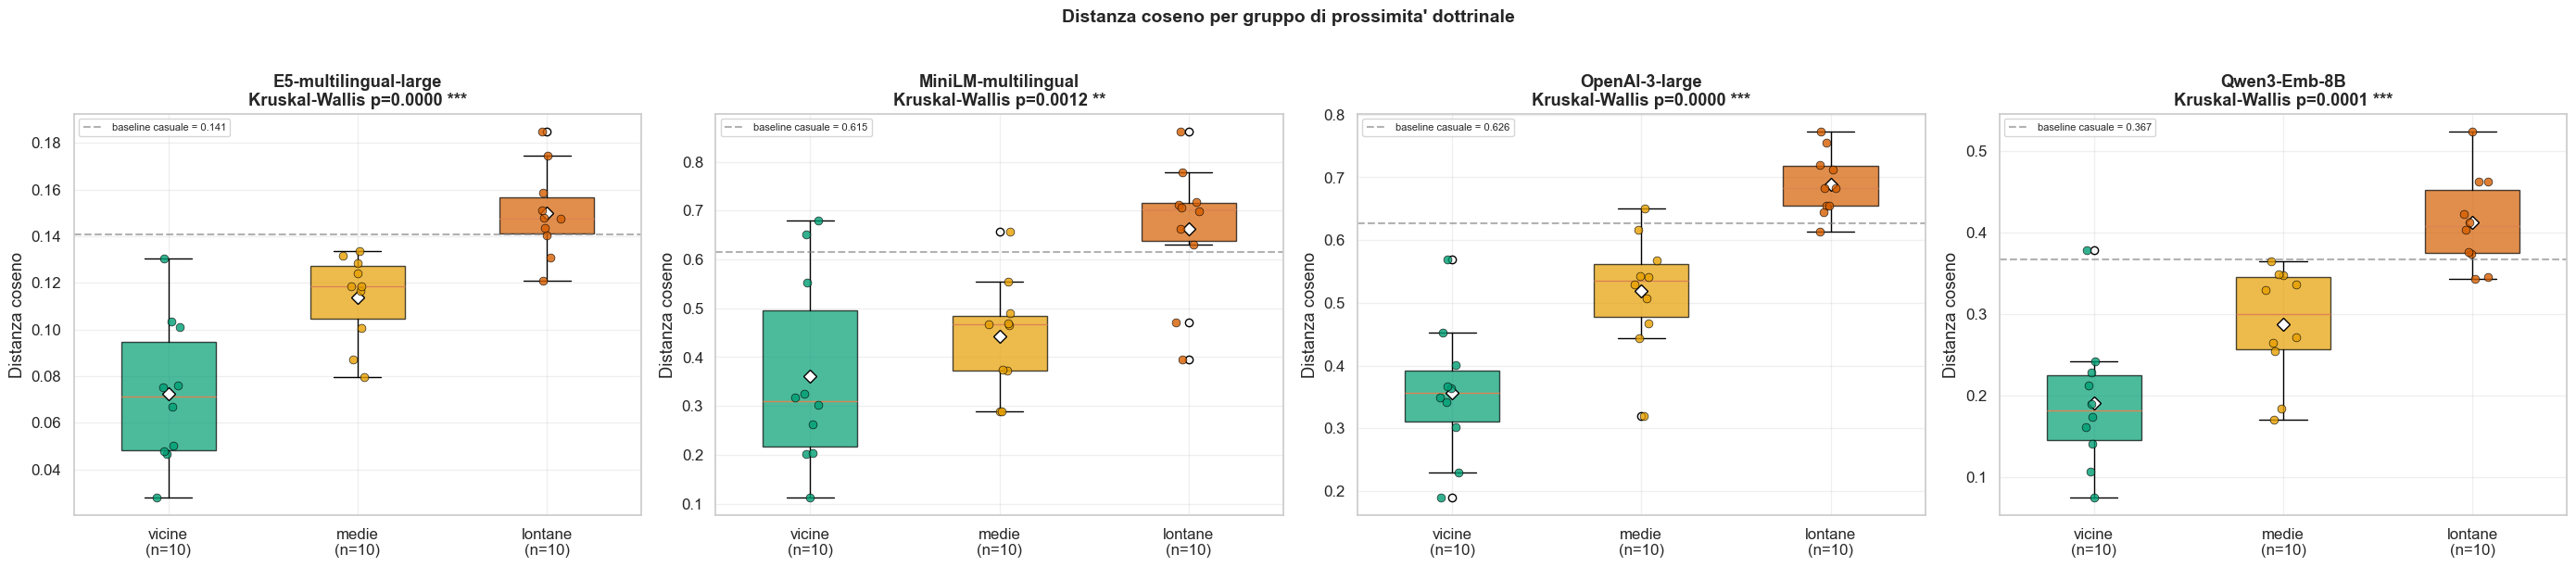

In [9]:
# == 5.1 Box plot per gruppo ======================================

n_models = len(results)
fig, axes = plt.subplots(1, n_models, figsize=(7 * n_models, 6))
if n_models == 1:
    axes = [axes]

for ax, model_label in zip(axes, results):
    col = results[model_label]["col"]

    # Prepara dati per box plot
    data_groups = []
    labels_groups = []
    colors = []
    for gruppo in ["vicine", "medie", "lontane"]:
        mask = df_coppie["gruppo"] == gruppo
        vals = df_coppie.loc[mask, col].values
        data_groups.append(vals)
        labels_groups.append(f"{gruppo}\n(n={len(vals)})")
        colors.append(PALETTE_GROUPS[gruppo])

    bp = ax.boxplot(data_groups, labels=labels_groups, patch_artist=True,
                    widths=0.5, showmeans=True,
                    meanprops={"marker": "D", "markerfacecolor": "white",
                               "markeredgecolor": "black", "markersize": 7})
    for patch, color in zip(bp["boxes"], colors):
        patch.set_facecolor(color)
        patch.set_alpha(0.7)

    # Punti individuali (jittered)
    for i, (gruppo, vals) in enumerate(
        zip(["vicine", "medie", "lontane"], data_groups)
    ):
        jitter = np.random.normal(0, 0.04, size=len(vals))
        ax.scatter(
            np.full_like(vals, i + 1) + jitter, vals,
            color=PALETTE_GROUPS[gruppo], edgecolors="black",
            linewidth=0.5, s=40, alpha=0.8, zorder=5,
        )

    # Linea baseline
    bl_mean = results[model_label].get("baseline_mean", None)
    if bl_mean:
        ax.axhline(bl_mean, color="gray", linestyle="--", alpha=0.6,
                   label=f"baseline casuale = {bl_mean:.3f}")
        ax.legend(fontsize=8, loc="upper left")

    # Annotazione KW
    kw_stat, kw_p = results[model_label]["kw"]
    sig = "***" if kw_p < 0.001 else "**" if kw_p < 0.01 else "*" if kw_p < 0.05 else "n.s."
    ax.set_title(f"{model_label}\nKruskal-Wallis p={kw_p:.4f} {sig}",
                 fontweight="bold")
    ax.set_ylabel("Distanza coseno")
    ax.grid(True, alpha=0.3)

plt.suptitle(
    "Distanza coseno per gruppo di prossimita' dottrinale",
    fontsize=14, fontweight="bold", y=1.02,
)
plt.tight_layout()
plt.show()

/var/folders/9h/9rgcllzs3zl98mk9r243sbrw0000gn/T/ipykernel_23453/3167737768.py:24: UserWarning: Glyph 8321 (\N{SUBSCRIPT ONE}) missing from current font.
  plt.tight_layout()
/Users/gpuzio/Desktop/CODE/THESIS/cls_pipeline/.venv/lib/python3.12/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 8321 (\N{SUBSCRIPT ONE}) missing from current font.
  fig.canvas.print_figure(bytes_io, **kw)


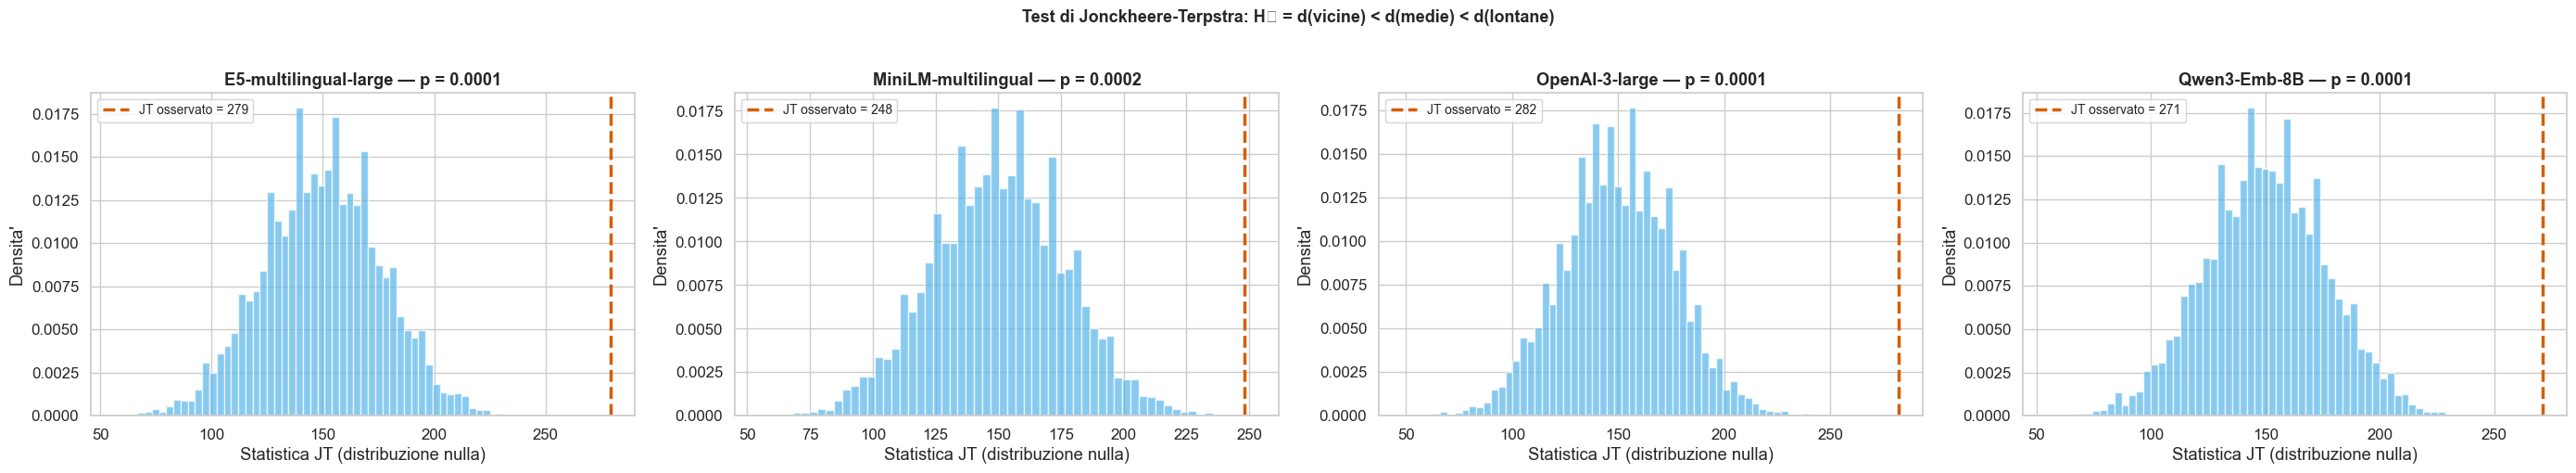

In [10]:
# == 5.2 Distribuzione nulla Jonckheere-Terpstra ==================

n_models = len(results)
fig, axes = plt.subplots(1, n_models, figsize=(7 * n_models, 5))
if n_models == 1:
    axes = [axes]

for ax, model_label in zip(axes, results):
    jt_stat, jt_p, jt_null = results[model_label]["jt"]

    ax.hist(jt_null, bins=60, density=True, alpha=0.7,
            color="#56B4E9", edgecolor="white")
    ax.axvline(jt_stat, color="#D55E00", linewidth=2.5, linestyle="--",
               label=f"JT osservato = {jt_stat:.0f}")
    ax.set_xlabel("Statistica JT (distribuzione nulla)")
    ax.set_ylabel("Densita'")
    ax.set_title(f"{model_label} — p = {jt_p:.4f}", fontweight="bold")
    ax.legend(fontsize=10)

plt.suptitle(
    "Test di Jonckheere-Terpstra: H\u2081 = d(vicine) < d(medie) < d(lontane)",
    fontsize=13, fontweight="bold", y=1.02,
)
plt.tight_layout()
plt.show()

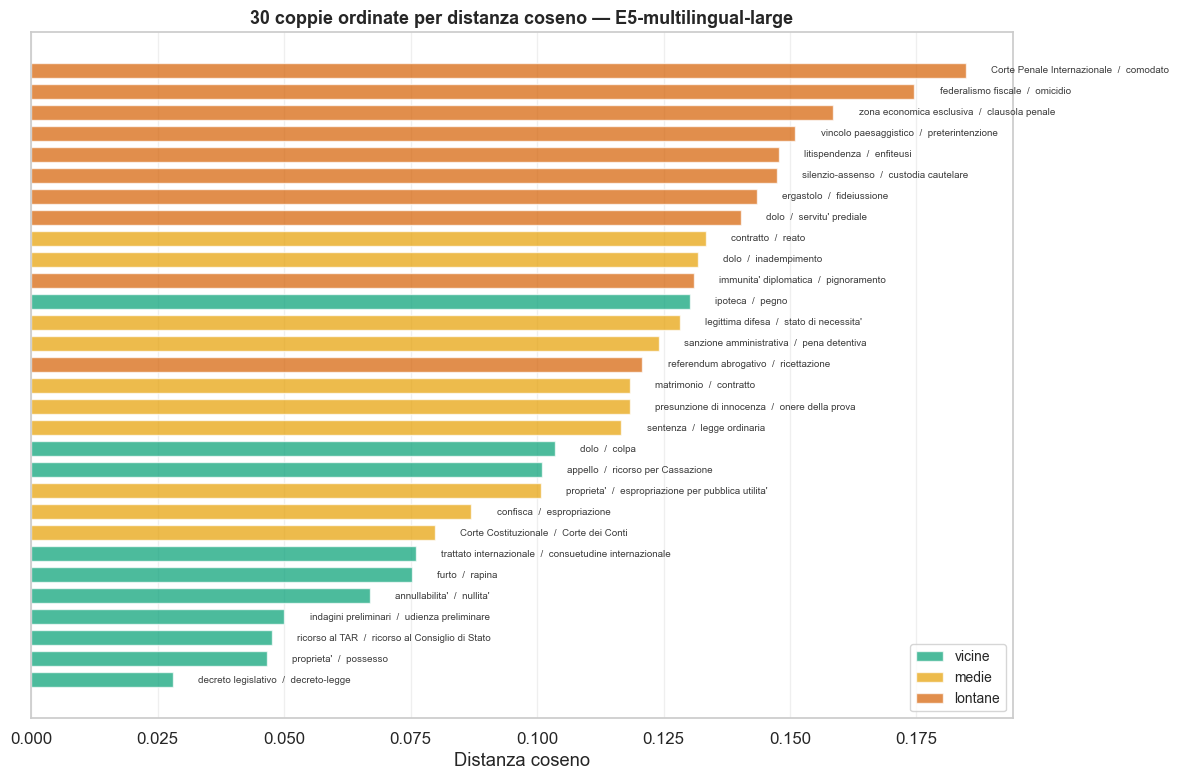

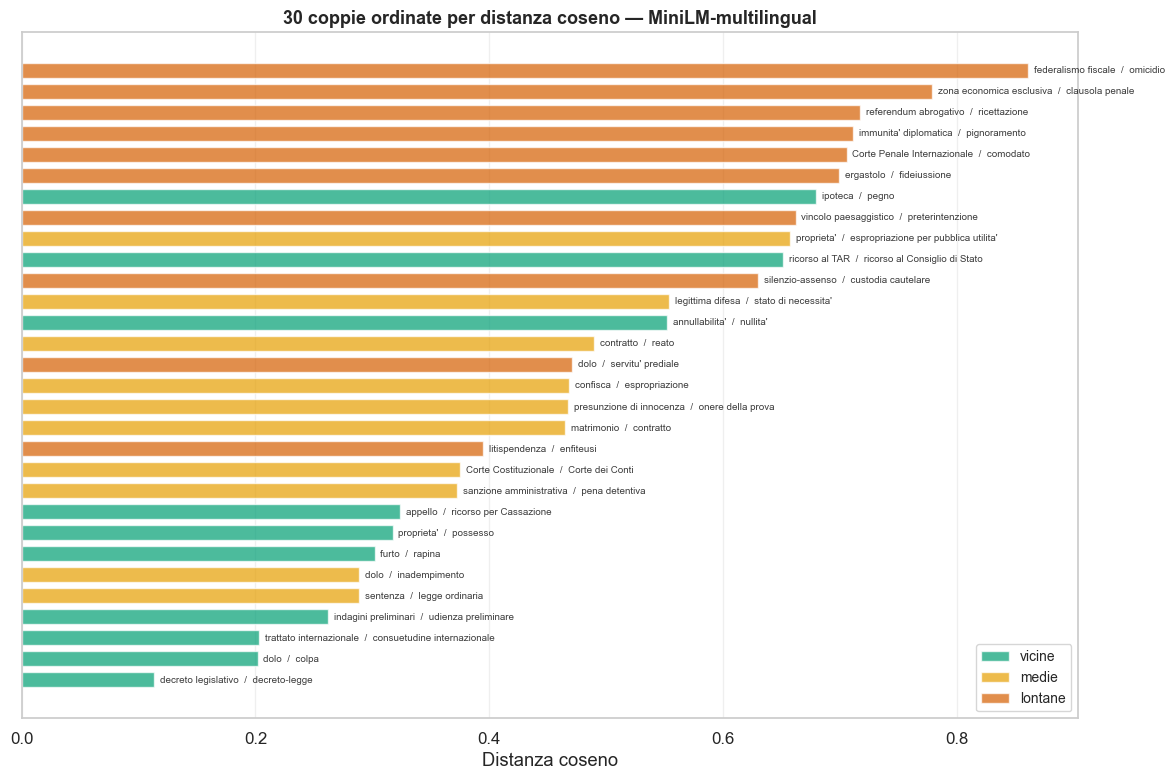

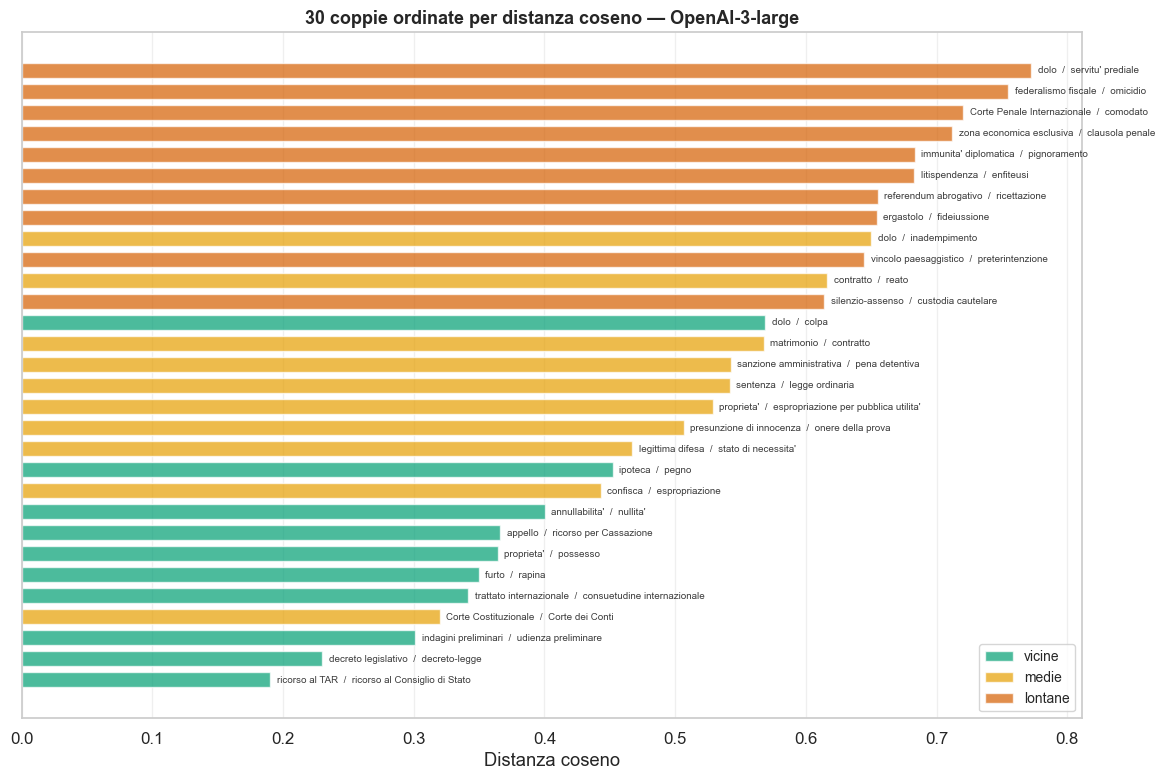

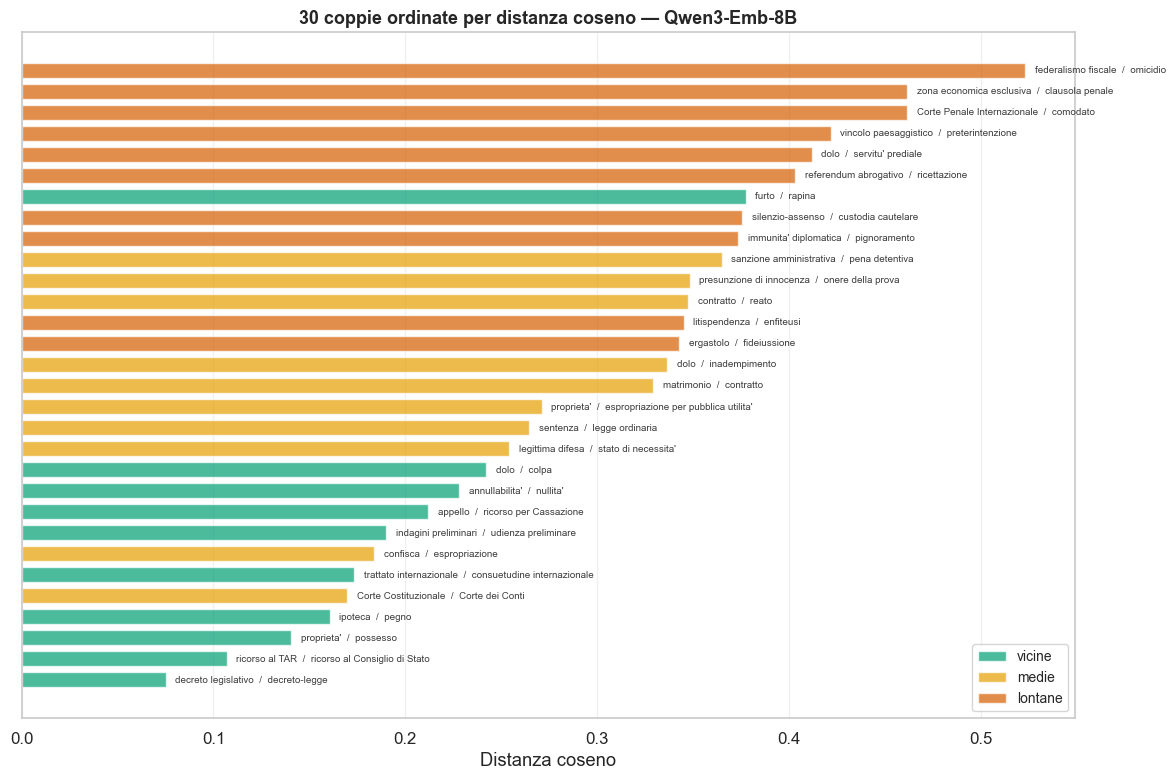

In [11]:
# == 5.3 Strip plot annotato ======================================
# Mostra ogni coppia con il nome, colorata per gruppo.

for model_label in results:
    col = results[model_label]["col"]

    fig, ax = plt.subplots(figsize=(12, 8))

    # Ordina per distanza
    df_sorted = df_coppie.sort_values(col, ascending=True).reset_index(drop=True)

    y_positions = range(len(df_sorted))
    for i, (_, row) in enumerate(df_sorted.iterrows()):
        color = PALETTE_GROUPS[row["gruppo"]]
        ax.barh(i, row[col], color=color, alpha=0.7, edgecolor="white", height=0.7)
        label = f"{row['a']}  /  {row['b']}"
        ax.text(row[col] + 0.005, i, label, va="center", fontsize=7, alpha=0.9)

    # Legenda manuale
    from matplotlib.patches import Patch
    legend_elements = [
        Patch(facecolor=PALETTE_GROUPS[g], alpha=0.7, label=g)
        for g in ["vicine", "medie", "lontane"]
    ]
    ax.legend(handles=legend_elements, loc="lower right", fontsize=10)

    ax.set_xlabel("Distanza coseno")
    ax.set_yticks([])
    ax.set_title(
        f"30 coppie ordinate per distanza coseno — {model_label}",
        fontsize=13, fontweight="bold",
    )
    ax.grid(True, axis="x", alpha=0.3)
    plt.tight_layout()
    plt.show()

Termini unici nelle coppie: 56


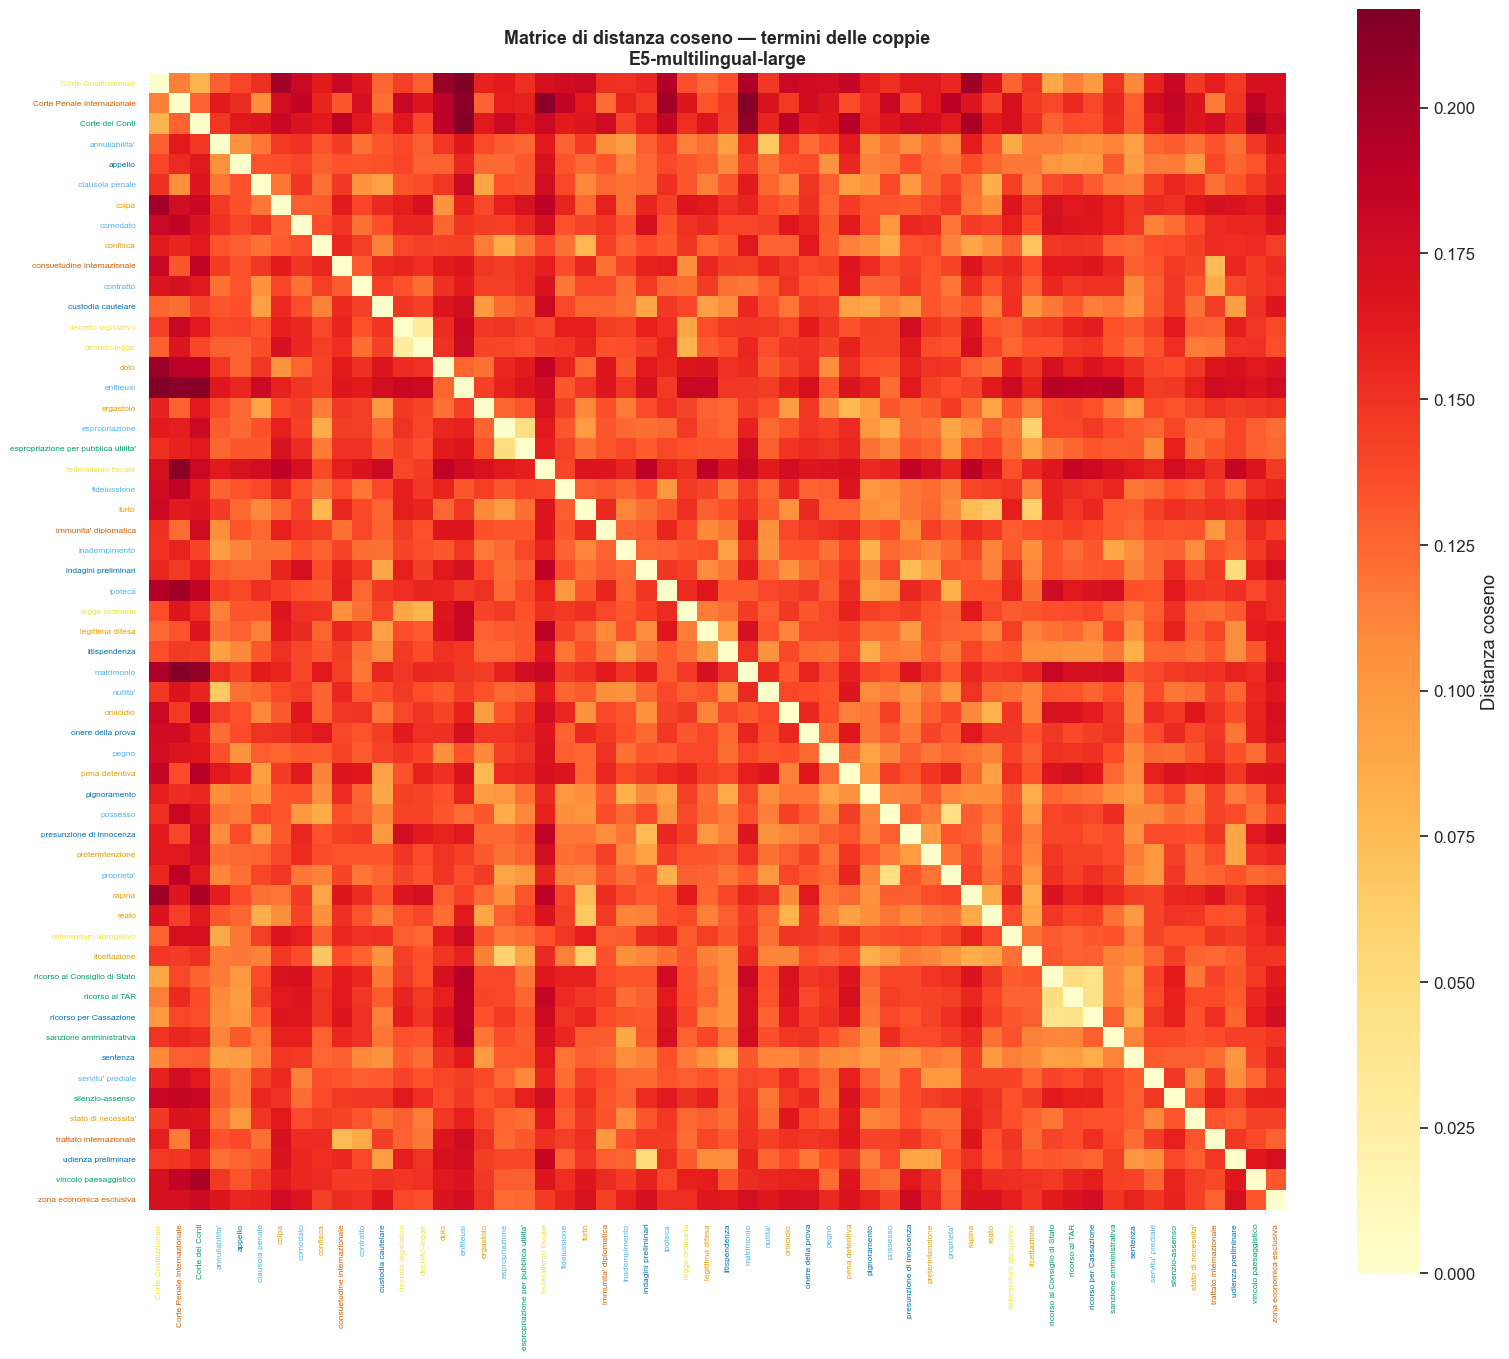

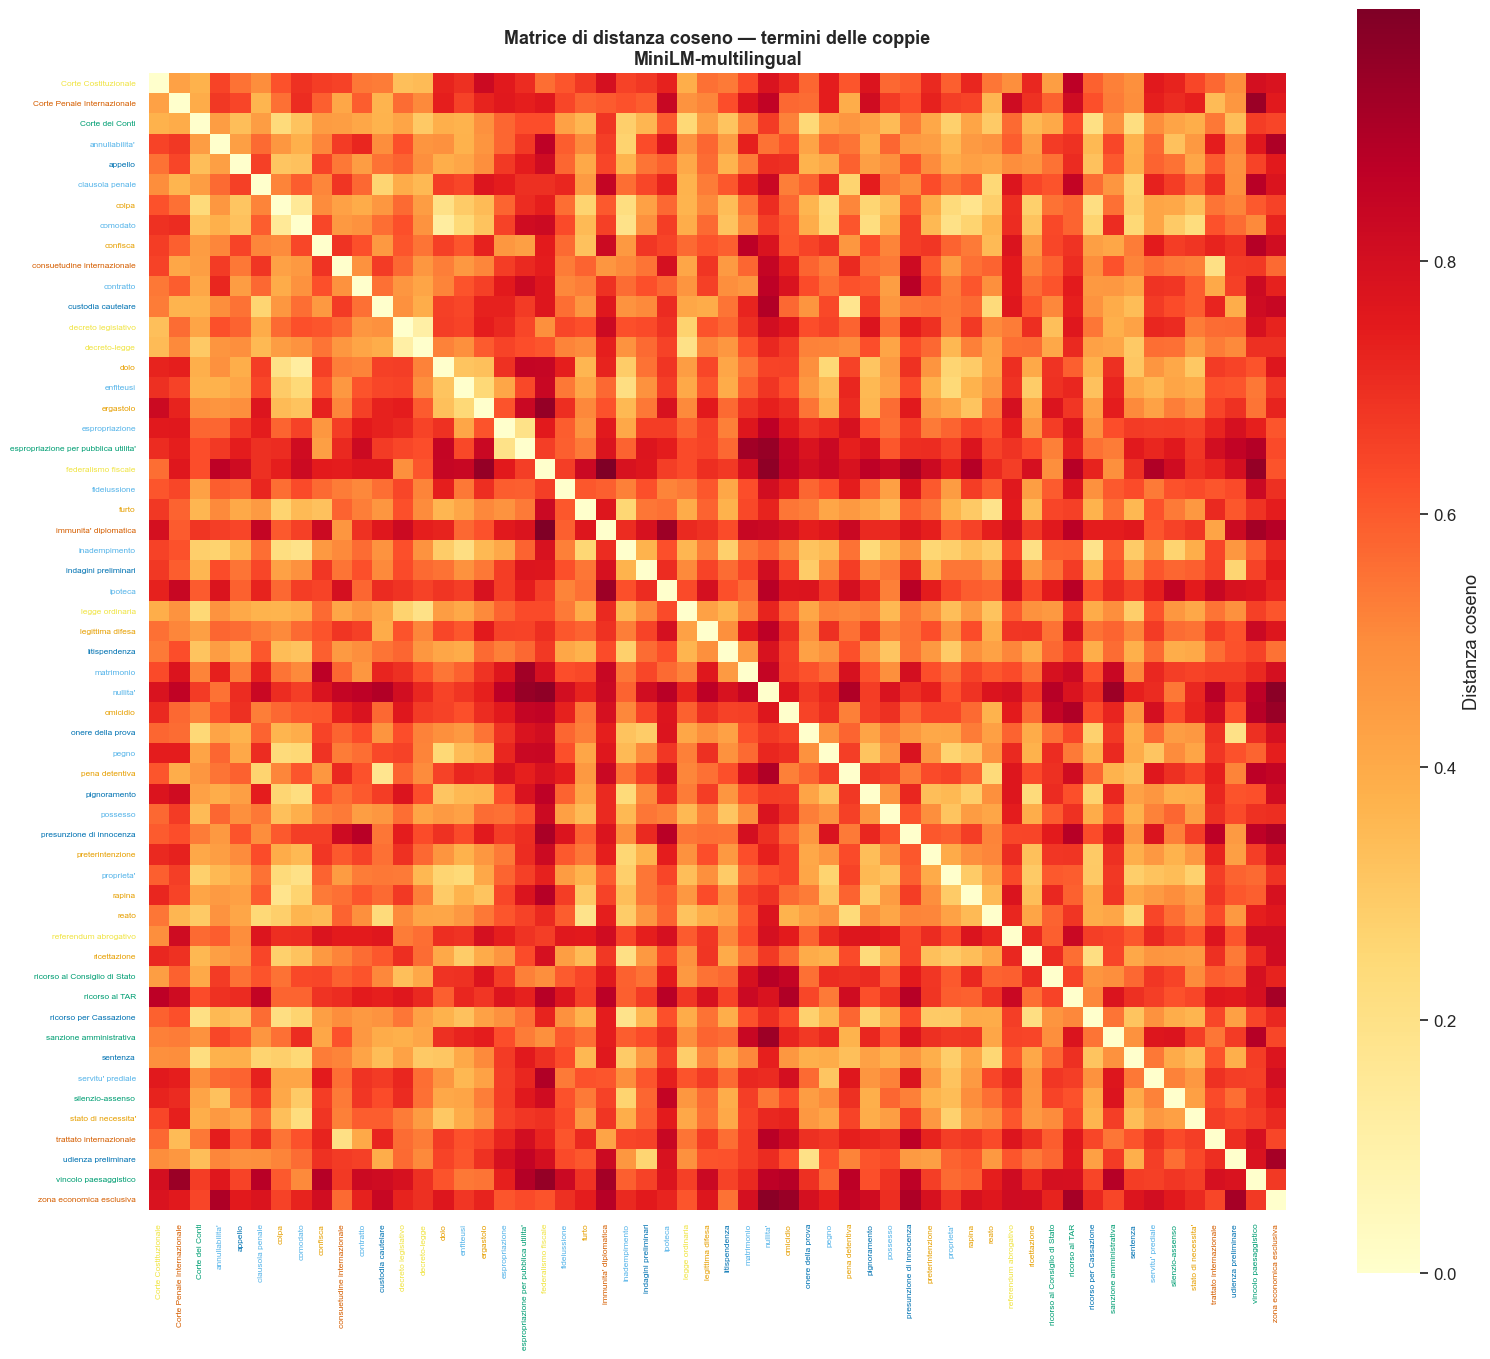

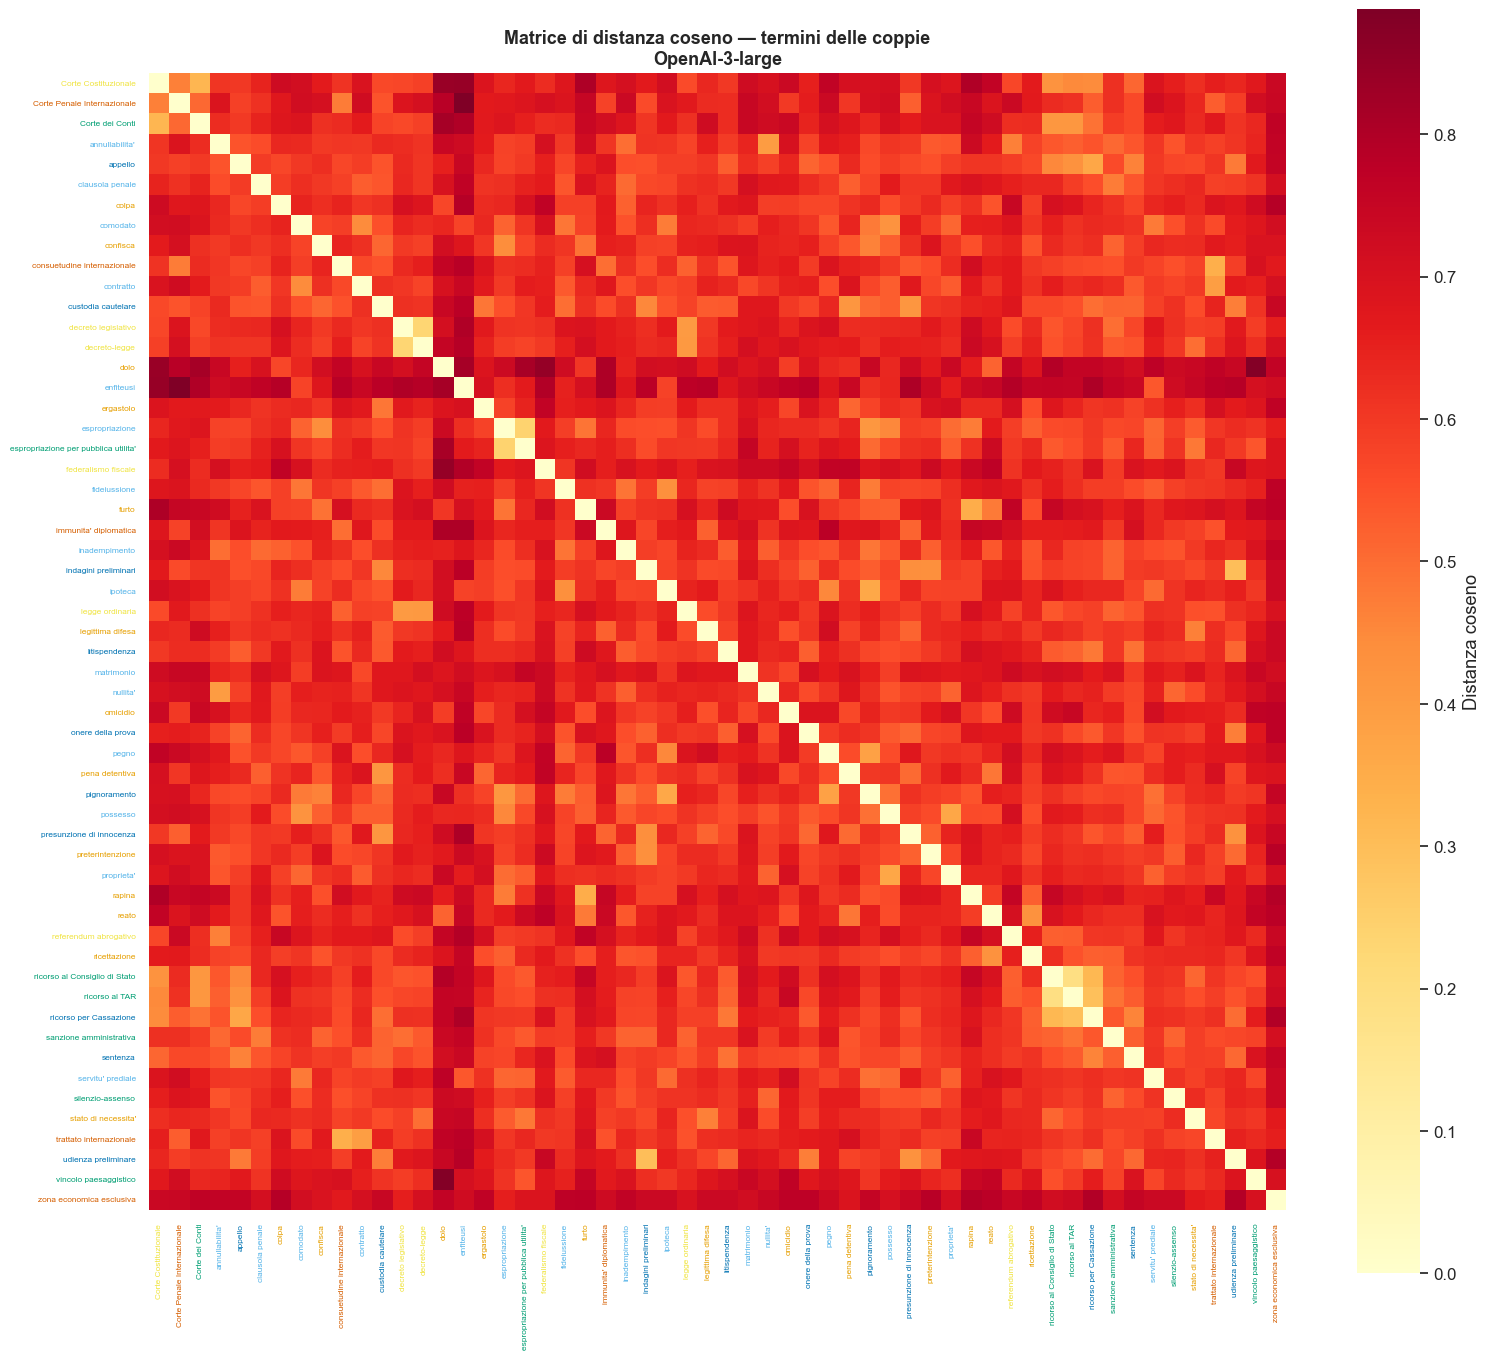

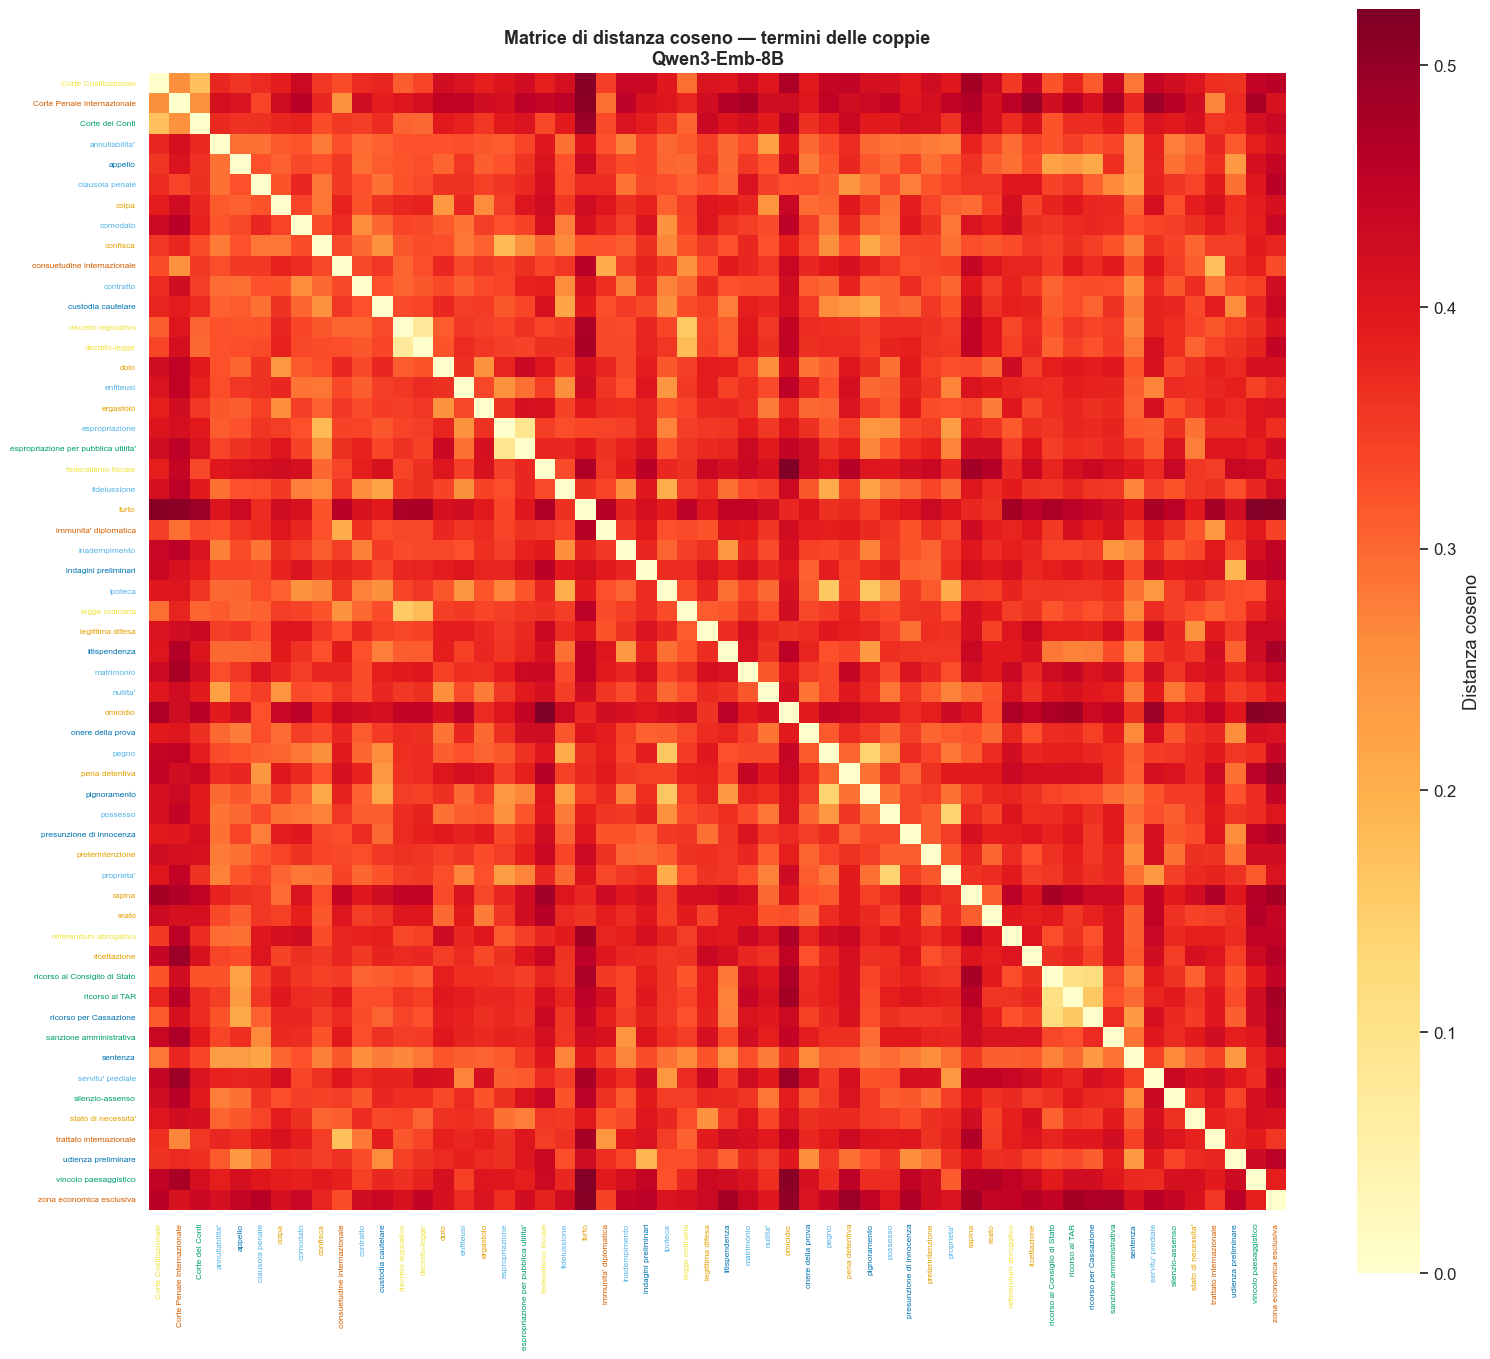

In [12]:
# == 5.4 Heatmap delle distanze tra i termini coinvolti ============
# Matrice di distanza coseno tra tutti i termini unici nelle 30 coppie.

# Raccogli termini unici
termini_coppie = sorted(set(
    [c["a"] for c in COPPIE] + [c["b"] for c in COPPIE]
))
print(f"Termini unici nelle coppie: {len(termini_coppie)}")

for model_label, emb in embeddings.items():
    # Costruisci sotto-matrice di distanza
    n_t = len(termini_coppie)
    dist_matrix = np.zeros((n_t, n_t))
    for i, ti in enumerate(termini_coppie):
        for j, tj in enumerate(termini_coppie):
            if i != j:
                vi = emb[termine_to_idx[ti]]
                vj = emb[termine_to_idx[tj]]
                dist_matrix[i, j] = 1.0 - np.dot(vi, vj)

    # Annotazione: ramo di appartenenza per colorare le etichette
    rami_termini = [df.loc[df["termine"] == t, "ramo"].values[0] for t in termini_coppie]

    fig, ax = plt.subplots(figsize=(16, 14))
    sns.heatmap(
        dist_matrix, annot=False, cmap="YlOrRd",
        xticklabels=termini_coppie, yticklabels=termini_coppie,
        square=True, ax=ax,
        cbar_kws={"label": "Distanza coseno"},
    )

    # Colora le etichette per ramo
    for i, (label, ramo) in enumerate(zip(ax.get_yticklabels(), rami_termini)):
        label.set_color(PALETTE_RAMI.get(ramo, "black"))
        label.set_fontsize(6)
    for i, (label, ramo) in enumerate(zip(ax.get_xticklabels(), rami_termini)):
        label.set_color(PALETTE_RAMI.get(ramo, "black"))
        label.set_fontsize(6)

    ax.set_title(
        f"Matrice di distanza coseno — termini delle coppie\n{model_label}",
        fontsize=13, fontweight="bold",
    )
    plt.tight_layout()
    plt.show()

## Sezione 6: Annotazione esperta (variante forte)

### Perche' la variante con giudizio umano

La classificazione in 3 gruppi (vicine/medie/lontane) e' un'approssimazione grossolana: impone una scala ordinale a 3 livelli su una realta' che e' probabilmente continua. Due coppie "medie" potrebbero avere distanze dottrinali molto diverse tra loro.

La **variante forte** sostituisce la scala ordinale con una scala **continua** (1-10): ciascun giurista valuta la "distanza concettuale" di ogni coppia su una scala numerica. Questo permette di calcolare una correlazione Spearman $\rho$ vera, non una proxy basata sui ranghi dei gruppi.

---

### Protocollo di annotazione

1. **5 giuristi indipendenti** ricevono le 30 coppie in ordine casuale (diverso per ciascuno)
2. Ciascun giurista assegna un punteggio intero da 1 a 10:
   - **1** = concetti praticamente sinonimi o varianti dello stesso istituto
   - **5** = concetti dello stesso ambito ma con funzione diversa
   - **10** = concetti totalmente estranei, appartenenti a rami diversi del diritto
3. I giuristi lavorano **senza conoscere** la classificazione pre-assegnata (vicine/medie/lontane)
4. I giuristi **non comunicano** tra loro durante l'annotazione

---

### Krippendorff's alpha ($\alpha$)

Prima di usare i giudizi umani come "verita' a terra", dobbiamo verificare che i giuristi siano **d'accordo tra loro**. Il Krippendorff's alpha (1970, 2011) e' la misura standard di affidabilita' inter-valutatore, applicabile a qualsiasi numero di valutatori e scale di misura.

**Definizione**: $\alpha$ misura il rapporto tra il disaccordo osservato ($D_o$) e il disaccordo atteso per caso ($D_e$):

$$\alpha = 1 - \frac{D_o}{D_e}$$

Per dati su scala **intervallo** (come la nostra scala 1-10), il disaccordo tra due valori $c$ e $k$ e' $(c - k)^2$, e:

$$D_o = \frac{1}{n} \sum_{\text{items}} \sum_{c < k} (c - k)^2 \cdot o_{ck}$$

$$D_e = \frac{1}{n(n-1)} \sum_{c < k} (c - k)^2 \cdot n_c \cdot n_k$$

dove $o_{ck}$ e' il numero di volte che due valutatori hanno assegnato i valori $c$ e $k$ allo stesso item, e $n_c$ e' la frequenza marginale del valore $c$.

**Interpretazione**:

| $\alpha$ | Interpretazione |
|---------|----------------|
| $> 0.80$ | Accordo eccellente — i giudizi sono affidabili come verita' a terra |
| $0.67 - 0.80$ | Accordo buono — conclusioni provvisorie ammissibili |
| $< 0.67$ | Accordo insufficiente — i giudizi sono troppo eterogenei per costituire un benchmark |

**Proprieta'**:
- $\alpha = 1$: accordo perfetto tra tutti i valutatori
- $\alpha = 0$: il disaccordo osservato e' uguale a quello atteso per caso
- $\alpha < 0$: il disaccordo e' sistematico (peggiore del caso)

**Vantaggio rispetto al Cohen's kappa**: il Cohen's kappa funziona solo per 2 valutatori e scale nominali. Il Krippendorff's alpha gestisce $n$ valutatori, dati mancanti, e scale ordinali/intervallo.

---

### Spearman $\rho$ tra distanza coseno e giudizio umano

Dopo aver verificato l'affidabilita' dei giuristi ($\alpha > 0.67$), calcoliamo il giudizio medio per ciascuna coppia e lo usiamo come **variabile di riferimento**. Il coefficiente di Spearman misura la correlazione **monotona** (non necessariamente lineare) tra i ranghi:

$$\rho = 1 - \frac{6 \sum d_i^2}{n(n^2 - 1)}$$

dove $d_i = \text{rango}(x_i) - \text{rango}(y_i)$ e $n = 30$ coppie. Il range e' $[-1, +1]$:
- $\rho = +1$: corrispondenza perfetta dei ranghi (ordinamento identico)
- $\rho = 0$: nessuna relazione monotona
- $\rho = -1$: ordinamento invertito

**Perche' Spearman e non Pearson**: il Pearson misura la correlazione *lineare* ($y = ax + b$). Il nostro modello prevede solo una relazione *monotona* ("piu' dottrinalmente lontani $\implies$ piu' coseno-distanti"), non una proporzionalita' diretta. Il Spearman e' piu' appropriato perche' opera sui ranghi, non sui valori assoluti.

**Significativita'**: sotto $H_0$ ($\rho = 0$), la statistica $t = \rho \sqrt{\frac{n-2}{1-\rho^2}}$ segue una distribuzione $t(n-2)$. Per $n = 30$, la soglia a $\alpha = 0.01$ (bilaterale) e' $|\rho| > 0.463$.

---

### Connessione con la Representational Similarity Analysis (RSA)

L'annotazione esperta trasforma l'Esperimento 2 in una forma di **RSA** (Kriegeskorte et al., 2008):
- La **matrice di dissimilarita' umana** ($30 \times 30$ distanze dottrinali) e' il modello teorico
- La **matrice di dissimilarita' coseno** e' il dato empirico
- Lo Spearman $\rho$ tra le due matrici e' il test RSA classico

Questa connessione lega direttamente l'Esperimento 2 all'Esperimento 1 della pipeline CLS (che usa RSA tra matrici di dissimilarita' complete).

In [13]:
# == Annotazione esperta ==========================================

# Genera template CSV per i giuristi
output_dir = Path("../output/exp02_distanza")
output_dir.mkdir(parents=True, exist_ok=True)

template = df_coppie[["a", "b"]].copy()
# Ordine casuale per evitare bias da posizione
template = template.sample(frac=1, random_state=SEED).reset_index(drop=True)
template["giurista_1"] = ""
template["giurista_2"] = ""
template["giurista_3"] = ""
template["giurista_4"] = ""
template["giurista_5"] = ""
template.to_csv(output_dir / "template_annotazione.csv", index=False)
print(f"Template salvato: {output_dir / 'template_annotazione.csv'}")
print("Istruzioni: ciascun giurista assegna un punteggio 1-10 per ogni coppia.")
print("  1 = concetti praticamente sinonimi")
print("  10 = concetti totalmente estranei")

# Se i dati sono gia' disponibili, caricarli:
ANNOTAZIONI_FILE = output_dir / "annotazioni_giuristi.csv"

if ANNOTAZIONI_FILE.exists():
    df_ann = pd.read_csv(ANNOTAZIONI_FILE)
    giurista_cols = [c for c in df_ann.columns if c.startswith("giurista_")]

    # Media dei giudizi
    df_ann["distanza_umana"] = df_ann[giurista_cols].mean(axis=1)

    # Merge con df_coppie (su a, b)
    df_merged = df_coppie.merge(df_ann[["a", "b", "distanza_umana"]], on=["a", "b"])

    print(f"\nAnnotazioni caricate: {len(giurista_cols)} giuristi")

    # Krippendorff's alpha (implementazione semplificata per dati intervallo)
    # Per una versione robusta: pip install krippendorff
    try:
        import krippendorff
        ratings = df_ann[giurista_cols].values.T  # raters x items
        alpha = krippendorff.alpha(ratings, level_of_measurement="interval")
        print(f"  Krippendorff's alpha = {alpha:.4f}")
        if alpha < 0.6:
            print("  ATTENZIONE: alpha < 0.6, accordo inter-valutatore insufficiente")
    except ImportError:
        print("  (krippendorff non installato, alpha non calcolato)")

    # Spearman rho per ciascun modello
    print(f"\n  Correlazione Spearman (distanza coseno vs. giudizio umano):")
    for model_label in results:
        col = results[model_label]["col"]
        rho, p = spearmanr(df_merged[col], df_merged["distanza_umana"])
        sig = "***" if p < 0.001 else "**" if p < 0.01 else "*" if p < 0.05 else "n.s."
        print(f"    {model_label}: rho={rho:.4f}, p={p:.6f} {sig}")
        results[model_label]["rho_umana"] = (rho, p)

    # Scatter plot
    for model_label in results:
        col = results[model_label]["col"]
        fig, ax = plt.subplots(figsize=(8, 6))

        for gruppo in ["vicine", "medie", "lontane"]:
            mask = df_merged["gruppo"] == gruppo
            ax.scatter(
                df_merged.loc[mask, "distanza_umana"],
                df_merged.loc[mask, col],
                color=PALETTE_GROUPS[gruppo], label=gruppo,
                s=60, alpha=0.8, edgecolors="black", linewidth=0.5,
            )

        # Retta di regressione
        x = df_merged["distanza_umana"].values
        y = df_merged[col].values
        m, b = np.polyfit(x, y, 1)
        x_line = np.linspace(x.min(), x.max(), 100)
        ax.plot(x_line, m * x_line + b, "--", color="gray", alpha=0.6)

        rho_val = results[model_label].get("rho_umana", (0, 1))
        ax.set_xlabel("Distanza dottrinale (giudizio umano medio, 1-10)")
        ax.set_ylabel("Distanza coseno")
        ax.set_title(
            f"Correlazione giudizio umano vs. distanza coseno\n"
            f"{model_label} — rho={rho_val[0]:.3f}, p={rho_val[1]:.4f}",
            fontweight="bold",
        )
        ax.legend()
        plt.tight_layout()
        plt.show()

else:
    print(f"\nFile annotazioni non trovato: {ANNOTAZIONI_FILE}")
    print("Per attivare la variante con giudizio umano:")
    print("  1. Distribuire template_annotazione.csv ai giuristi")
    print("  2. Raccogliere i risultati in annotazioni_giuristi.csv")
    print("  3. Rieseguire questa cella")

Template salvato: ../output/exp02_distanza/template_annotazione.csv
Istruzioni: ciascun giurista assegna un punteggio 1-10 per ogni coppia.
  1 = concetti praticamente sinonimi
  10 = concetti totalmente estranei

File annotazioni non trovato: ../output/exp02_distanza/annotazioni_giuristi.csv
Per attivare la variante con giudizio umano:
  1. Distribuire template_annotazione.csv ai giuristi
  2. Raccogliere i risultati in annotazioni_giuristi.csv
  3. Rieseguire questa cella


In [14]:
# == Tabella riepilogativa comparativa =============================

rows = []
for model_label in results:
    r = results[model_label]
    col = r["col"]

    # Medie per gruppo
    d_vic = df_coppie.loc[df_coppie["gruppo"] == "vicine", col].mean()
    d_med = df_coppie.loc[df_coppie["gruppo"] == "medie", col].mean()
    d_lon = df_coppie.loc[df_coppie["gruppo"] == "lontane", col].mean()

    kw_stat, kw_p = r["kw"]
    jt_stat, jt_p, _ = r["jt"]
    rho_raw, p_raw = r.get("rho_raw", (float("nan"), float("nan")))

    rows.append({
        "Modello": model_label,
        "d(vicine)": f"{d_vic:.4f}",
        "d(medie)": f"{d_med:.4f}",
        "d(lontane)": f"{d_lon:.4f}",
        "Ordinamento": "v<m<l" if d_vic < d_med < d_lon else "VIOLATO",
        "KW p": f"{kw_p:.4f}",
        "JT p": f"{jt_p:.4f}",
        "rho(gruppo)": f"{rho_raw:.4f}",
        "Baseline": f"{r.get('baseline_mean', 0):.4f}",
    })

df_summary = pd.DataFrame(rows)
print("TABELLA RIEPILOGATIVA")
print("Esperimento 2: Distanza tra Istituti Affini")
print("=" * 90)
display(df_summary)

TABELLA RIEPILOGATIVA
Esperimento 2: Distanza tra Istituti Affini


,Modello,d(vicine),d(medie),d(lontane),Ordinamento,KW p,JT p,rho(gruppo),Baseline
0,E5-multilingual-large,0.0725,0.1139,0.1500,v<m<l,0.0000,0.0001,0.8396,0.1409
1,MiniLM-multilingual,0.3607,0.4427,0.6632,v<m<l,0.0012,0.0002,0.6556,0.6145
2,OpenAI-3-large,0.3564,0.5183,0.6894,v<m<l,0.0000,0.0001,0.8584,0.6260
3,Qwen3-Emb-8B,0.1906,0.2870,0.4121,v<m<l,0.0001,0.0001,0.7877,0.3670


## Sezione 7: Interpretazione dei risultati

### Guida all'interpretazione

| Scenario | KW / JT | rho Spearman | Significato |
|----------|---------|-------------|-------------|
| **A** (teoria confermata forte) | p < 0.001, JT sig. | rho > 0.6 | Lo spazio degli embedding preserva la topologia del diritto |
| **B** (conferma parziale) | p < 0.05, solo vicine != lontane | 0.3 < rho < 0.6 | Solo le macro-distanze sono catturate |
| **C** (effetto modello-dipendente) | Sig. solo per un modello | rho alto solo per specializzato | La struttura c'e' ma richiede specializzazione |
| **D** (confutazione) | p > 0.05 | rho < 0.2 | La distanza coseno non riflette la prossimita' dottrinale |

### Prossimi passi per scenario

- **Se A**: forte evidenza. Procedere con Esp. 6-7 (aritmetica vettoriale e direzioni semantiche).
- **Se B**: la geometria e' "coarse-grained". Servono modelli piu' grandi o specializzati per le sfumature. L'Esp. 3 diventa critico.
- **Se C**: conferma la formula Qualita' = Capacita' x Pertinenza (par. 5.2 del documento teorico). Aggiungere voyage-law-2.
- **Se D**: la distanza coseno potrebbe non essere la metrica giusta. Provare: (a) distanza euclidea, (b) learned metric, (c) embedding contestualizzati (frasi intere anziche' termini singoli).

### Connessione con Esperimento 1

L'Esperimento 1 testa la struttura categoriale ("i termini si raggruppano per ramo?"). L'Esperimento 2 testa la struttura metrica ("le distanze riflettono la prossimita'?"). E' possibile che l'Esp. 1 dia ARI alto ma l'Esp. 2 dia rho basso: i termini potrebbero clusterizzare correttamente ma con distanze interne non informative.

### Confound residui

- **Overlap lessicale**: controllato nella Sezione 4. Se la correlazione cala significativamente escludendo le coppie con overlap, l'effetto e' in parte lessicale.
- **Anisotropia**: la baseline mostra la distanza media "attesa" tra coppie casuali. Le coppie vicine devono essere significativamente sotto questa baseline.
- **N piccolo**: 10 coppie per gruppo limitano la potenza statistica. La variante con giudizio umano (Sezione 6) mitiga usando il continuum 1-10 anziche' 3 categorie.

In [15]:
# == Salvataggio risultati =========================================

output_dir = Path("../output/exp02_distanza")
output_dir.mkdir(parents=True, exist_ok=True)

# Coppie con distanze
export_cols = ["a", "b", "gruppo", "motivazione", "jaccard_overlap"]
export_cols += [r["col"] for r in results.values()]
df_coppie[export_cols].to_csv(output_dir / "coppie_distanze.csv", index=False)

# Metriche
metrics_export = {}
for model_label in results:
    r = results[model_label]
    col = r["col"]
    d_vic = df_coppie.loc[df_coppie["gruppo"] == "vicine", col].mean()
    d_med = df_coppie.loc[df_coppie["gruppo"] == "medie", col].mean()
    d_lon = df_coppie.loc[df_coppie["gruppo"] == "lontane", col].mean()

    metrics_export[model_label] = {
        "mean_vicine": float(d_vic),
        "mean_medie": float(d_med),
        "mean_lontane": float(d_lon),
        "ordinamento_rispettato": bool(d_vic < d_med < d_lon),
        "kruskal_wallis": {"H": float(r["kw"][0]), "p": float(r["kw"][1])},
        "jonckheere_terpstra": {"JT": float(r["jt"][0]), "p": float(r["jt"][1])},
        "spearman_gruppo": {"rho": float(r["rho_raw"][0]), "p": float(r["rho_raw"][1])},
        "baseline_mean": float(r.get("baseline_mean", 0)),
    }

with open(output_dir / "metrics.json", "w", encoding="utf-8") as f:
    json.dump(metrics_export, f, indent=2)

print(f"Risultati salvati in: {output_dir}")
print(f"  coppie_distanze.csv: 30 coppie con distanze per {len(results)} modelli")
print(f"  metrics.json: statistiche per {len(results)} modelli")
print(f"  template_annotazione.csv: template per annotazione esperta")

print("\n" + "=" * 70)
print("  ESPERIMENTO 2 COMPLETATO")
print("=" * 70)

Risultati salvati in: ../output/exp02_distanza
  coppie_distanze.csv: 30 coppie con distanze per 4 modelli
  metrics.json: statistiche per 4 modelli
  template_annotazione.csv: template per annotazione esperta

  ESPERIMENTO 2 COMPLETATO
